# Main

In [1]:
import logging
logging.basicConfig(level=logging.ERROR, format="%(asctime)s %(name)s %(levelname)s %(message)s")

from src.experimenthandling import ExperimentAnalyzer

In [2]:
def load_and_return(experiment: str) -> ExperimentAnalyzer:
    exp = ExperimentAnalyzer(experiment)
    # exp.load_models()
    exp.load_metrics()
    return exp



In [3]:
exp1a = load_and_return('experiment_1a')

In [5]:
graph_dict = {
    'graph1': r'$\mathcal{G}_I$',
    'graph2': r'$\mathcal{G}_{GCG}$',
    'graph3': r'$\mathcal{G}_R(3)$',
    'graph4': r'$\mathcal{G}_R(4)$',
    'graph5': r'$\mathcal{G}_R(5)$',
    'graph6': r'$\mathcal{G}_R(6)$',
}

In [6]:
# note: takes around 5 minutes to run this!
exp1a = load_and_return('experiment_1a')
exp1b = load_and_return('experiment_1b')
exp1c = load_and_return('experiment_1c')
exp1d = load_and_return('experiment_1d')
exp2a = load_and_return('experiment_2a')
exp2b = load_and_return('experiment_2b')
exp2c = load_and_return('experiment_2c')
exp2d = load_and_return('experiment_2d')
exp3a = load_and_return('experiment_3a')
exp3b = load_and_return('experiment_3b')
exp3c = load_and_return('experiment_3c')
exp3d = load_and_return('experiment_3d')
exp4a = load_and_return('experiment_4a')
exp4b = load_and_return('experiment_4b')
exp4c = load_and_return('experiment_4c')

In [4]:
"""
figure_style.py
----------------
Standardized figure formatting utilities for consistent axes tags, titles,
labels, ticks, legends, and layout across all paper figures.

Usage pattern:

    fig, gs = ...            # build your gridspec / axes as before
    fig, axes = finalize_layout(fig, [ax1, ax2, ax3, ax4], figure2_style,
                                 [axes0_style, axes1_style, axes2_style, axes3_style])
    align_axes_to_reference(fig, ref_ax=ax1, other_axes=[ax2, ax3, ax4])
    fig.savefig(..., bbox_inches="tight")
"""

from dataclasses import dataclass, field

import matplotlib
from matplotlib.axes import Axes
from matplotlib.figure import Figure


# --------------------------------------------------------------------------
# Style dataclasses
# --------------------------------------------------------------------------

@dataclass
class GlobalFigureConfig:
    """Journal-wide defaults. Change these once, and every figure updates."""

    label_size:     float = 8
    tick_size:      float = 7
    title_size:     float = 9
    legend_size:    float = 8

    suptitle_size:  float = 10
    suptitle_fontweight: str = 'bold'

    tick_width:     float = 0.8
    spine_width:    float = 0.8

    tag_args: dict = field(
        default_factory=lambda: {
            "x": -0.06,
            "y": 1.05,
            "fontsize": 16,
            "fontweight": "bold",
            "va": "bottom",
            "ha": "right",
        }
    )


@dataclass
class AxesStyle:
    title:          str | None = None
    label_x:        str | None = None
    label_y:        str | None = None
    tag:            str | None = None

    ticks_x:        bool = True
    ticks_x_labels: bool = True
    ticks_x_args:   dict = field(default_factory=dict)

    ticks_y:        bool = True
    ticks_y_labels: bool = True
    ticks_y_args:   dict = field(default_factory=dict)

    legend:         bool = False
    legend_args:    dict = field(default_factory=dict)
    legend_labels:  dict[str, str] | None = None
     

    show_grid:      bool = False
    spines:         bool | dict[str, bool] = True

    # per-axes overrides of the global defaults (None -> use global)
    tick_width:     float | None = None
    spine_width:    float | None = None


@dataclass
class FigureStyle:
    figsize:        tuple = (3.5, 3.0)
    dpi:            int = 300
    suptitle:       str | None = None
    num_subfigures: int = 1

    suptitle_args: dict = field(
        default_factory=lambda: {
            "ha": "left",
            "x": 0.02,
        }
    )


global_figure_cfg = GlobalFigureConfig()


# --------------------------------------------------------------------------
# Core formatting pass
# --------------------------------------------------------------------------

def finalize_layout(
    fig: Figure,
    ax: Axes | list[Axes],
    fig_cfg: FigureStyle,
    ax_cfg: AxesStyle | list[AxesStyle],
    global_cfg: GlobalFigureConfig = global_figure_cfg,
):
    """Apply titles, labels, tags, ticks, legends, and global styling.

    NOTE: this only sets cosmetic properties. It does not touch axes
    *positions* -- do that afterwards with align_axes_to_reference(), once
    all labels/legends are in and the layout engine has had a chance to
    compute a first pass.
    """

    axes_list = [ax] if isinstance(ax, Axes) else list(ax)
    cfg_list = [ax_cfg] if isinstance(ax_cfg, AxesStyle) else list(ax_cfg)

    if len(axes_list) != len(cfg_list):
        raise ValueError("len of ax and ax_cfg need to be the same!")

    # --- figure-level style -------------------------------------------------
    if fig_cfg.figsize:
        fig.set_size_inches(*fig_cfg.figsize)
    if fig_cfg.dpi:
        fig.set_dpi(fig_cfg.dpi)
    if fig_cfg.suptitle:
        fig.suptitle(fig_cfg.suptitle, fontsize = global_figure_cfg.suptitle_size, fontweight = global_figure_cfg.suptitle_fontweight, **fig_cfg.suptitle_args)

    # --- per-axes style ------------------------------------------------------
    for cur_ax, cfg in zip(axes_list, cfg_list):

        # titles / labels
        cur_ax.set_xlabel(cfg.label_x, fontsize=global_cfg.label_size)
        cur_ax.set_ylabel(cfg.label_y, fontsize=global_cfg.label_size)
        cur_ax.set_title(cfg.title, fontsize=global_cfg.title_size, loc="left")

        if cfg.tag:
            cur_ax.text(s=cfg.tag, transform=cur_ax.transAxes, **global_cfg.tag_args)

        # ticks
        if not cfg.ticks_x:
            cur_ax.set_xticks([])
        else:
            if not cfg.ticks_x_labels:
                cur_ax.tick_params(axis="x", labelbottom=False)
            cur_ax.tick_params(axis="x", labelsize=global_cfg.tick_size, **cfg.ticks_x_args)

        if not cfg.ticks_y:
            cur_ax.set_yticks([])
        else:
            if not cfg.ticks_y_labels:
                cur_ax.tick_params(axis="y", labelleft=False)  # was labelbottom (bug)
            cur_ax.tick_params(axis="y", labelsize=global_cfg.tick_size, **cfg.ticks_y_args)

       # tick + spine width (global default, overridable per-axes)
        tick_width = cfg.tick_width if cfg.tick_width is not None else global_cfg.tick_width
        spine_width = cfg.spine_width if cfg.spine_width is not None else global_cfg.spine_width
        cur_ax.tick_params(width=tick_width)
        for spine in cur_ax.spines.values():
            spine.set_linewidth(spine_width)
 
        # spines (the box around the plot)
        if isinstance(cfg.spines, bool):
            if not cfg.spines:
                for spine in cur_ax.spines.values():
                    spine.set_visible(False)
        else:
            for side, visible in cfg.spines.items():
                if side in cur_ax.spines:
                    cur_ax.spines[side].set_visible(visible)

        # grid
        cur_ax.grid(cfg.show_grid)

        # legend
        existing_legend = cur_ax.get_legend()
        if not cfg.legend:
            if existing_legend is not None:
                existing_legend.remove()
        else:
            handles, labels = cur_ax.get_legend_handles_labels()
            if cfg.legend_labels:
                labels = [cfg.legend_labels.get(l, l) for l in labels]
            legend_kwargs = {"fontsize": global_cfg.legend_size, **cfg.legend_args}
            if handles:
                # Real labeled artists exist (e.g. sns.lineplot(..., label=...)),
                # which is also why a legend may already exist here -- seaborn
                # auto-creates one as soon as label= is passed, even without
                # hue=. Recreate cleanly so loc/ncols/etc. in legend_args
                # actually take effect, instead of just restyling whatever
                # seaborn already built.
                cur_ax.legend(handles, labels, **legend_kwargs)
            elif existing_legend is not None:
                # Legend was built manually from handles with no `label` set
                # on the underlying artists (e.g. custom Rectangle swatches
                # via ax.legend(handles, labels, ...)) -- get_legend_handles_labels
                # can't recover those, so recreating would silently produce an
                # empty legend. Just restyle the existing one's text in place.
                for text in existing_legend.get_texts():
                    if cfg.legend_labels:
                        text.set_text(cfg.legend_labels.get(text.get_text(), text.get_text()))
                    text.set_fontsize(legend_kwargs["fontsize"])
 
    return fig, axes_list
 


# --------------------------------------------------------------------------
# Position alignment (do this AFTER finalize_layout + a draw pass)
# --------------------------------------------------------------------------

def align_axes_to_reference(fig: Figure, ref_ax: Axes, other_axes: list[Axes]) -> None:
    """Force every axis in `other_axes` to share ref_ax's left edge/width.

    Call this once, after all plotting/labeling/legends are done (so tick
    labels etc. have already pushed the layout where they need to be), and
    after fig.canvas.draw() so get_position() reflects real content.
    """
    fig.canvas.draw()

    ref_pos = ref_ax.get_position()
    for other_ax in other_axes:
        pos = other_ax.get_position()
        other_ax.set_position([ref_pos.x0, pos.y0, ref_pos.width, pos.height])

    # freeze the layout so a later draw/save doesn't undo the alignment
    try:
        fig.set_layout_engine(None)          # matplotlib >= 3.6
    except AttributeError:
        fig.set_constrained_layout(False)    # older matplotlib fallback

    fig.canvas.draw()

# Figure 1: Visual Abstract

# Figure 2: Data splits

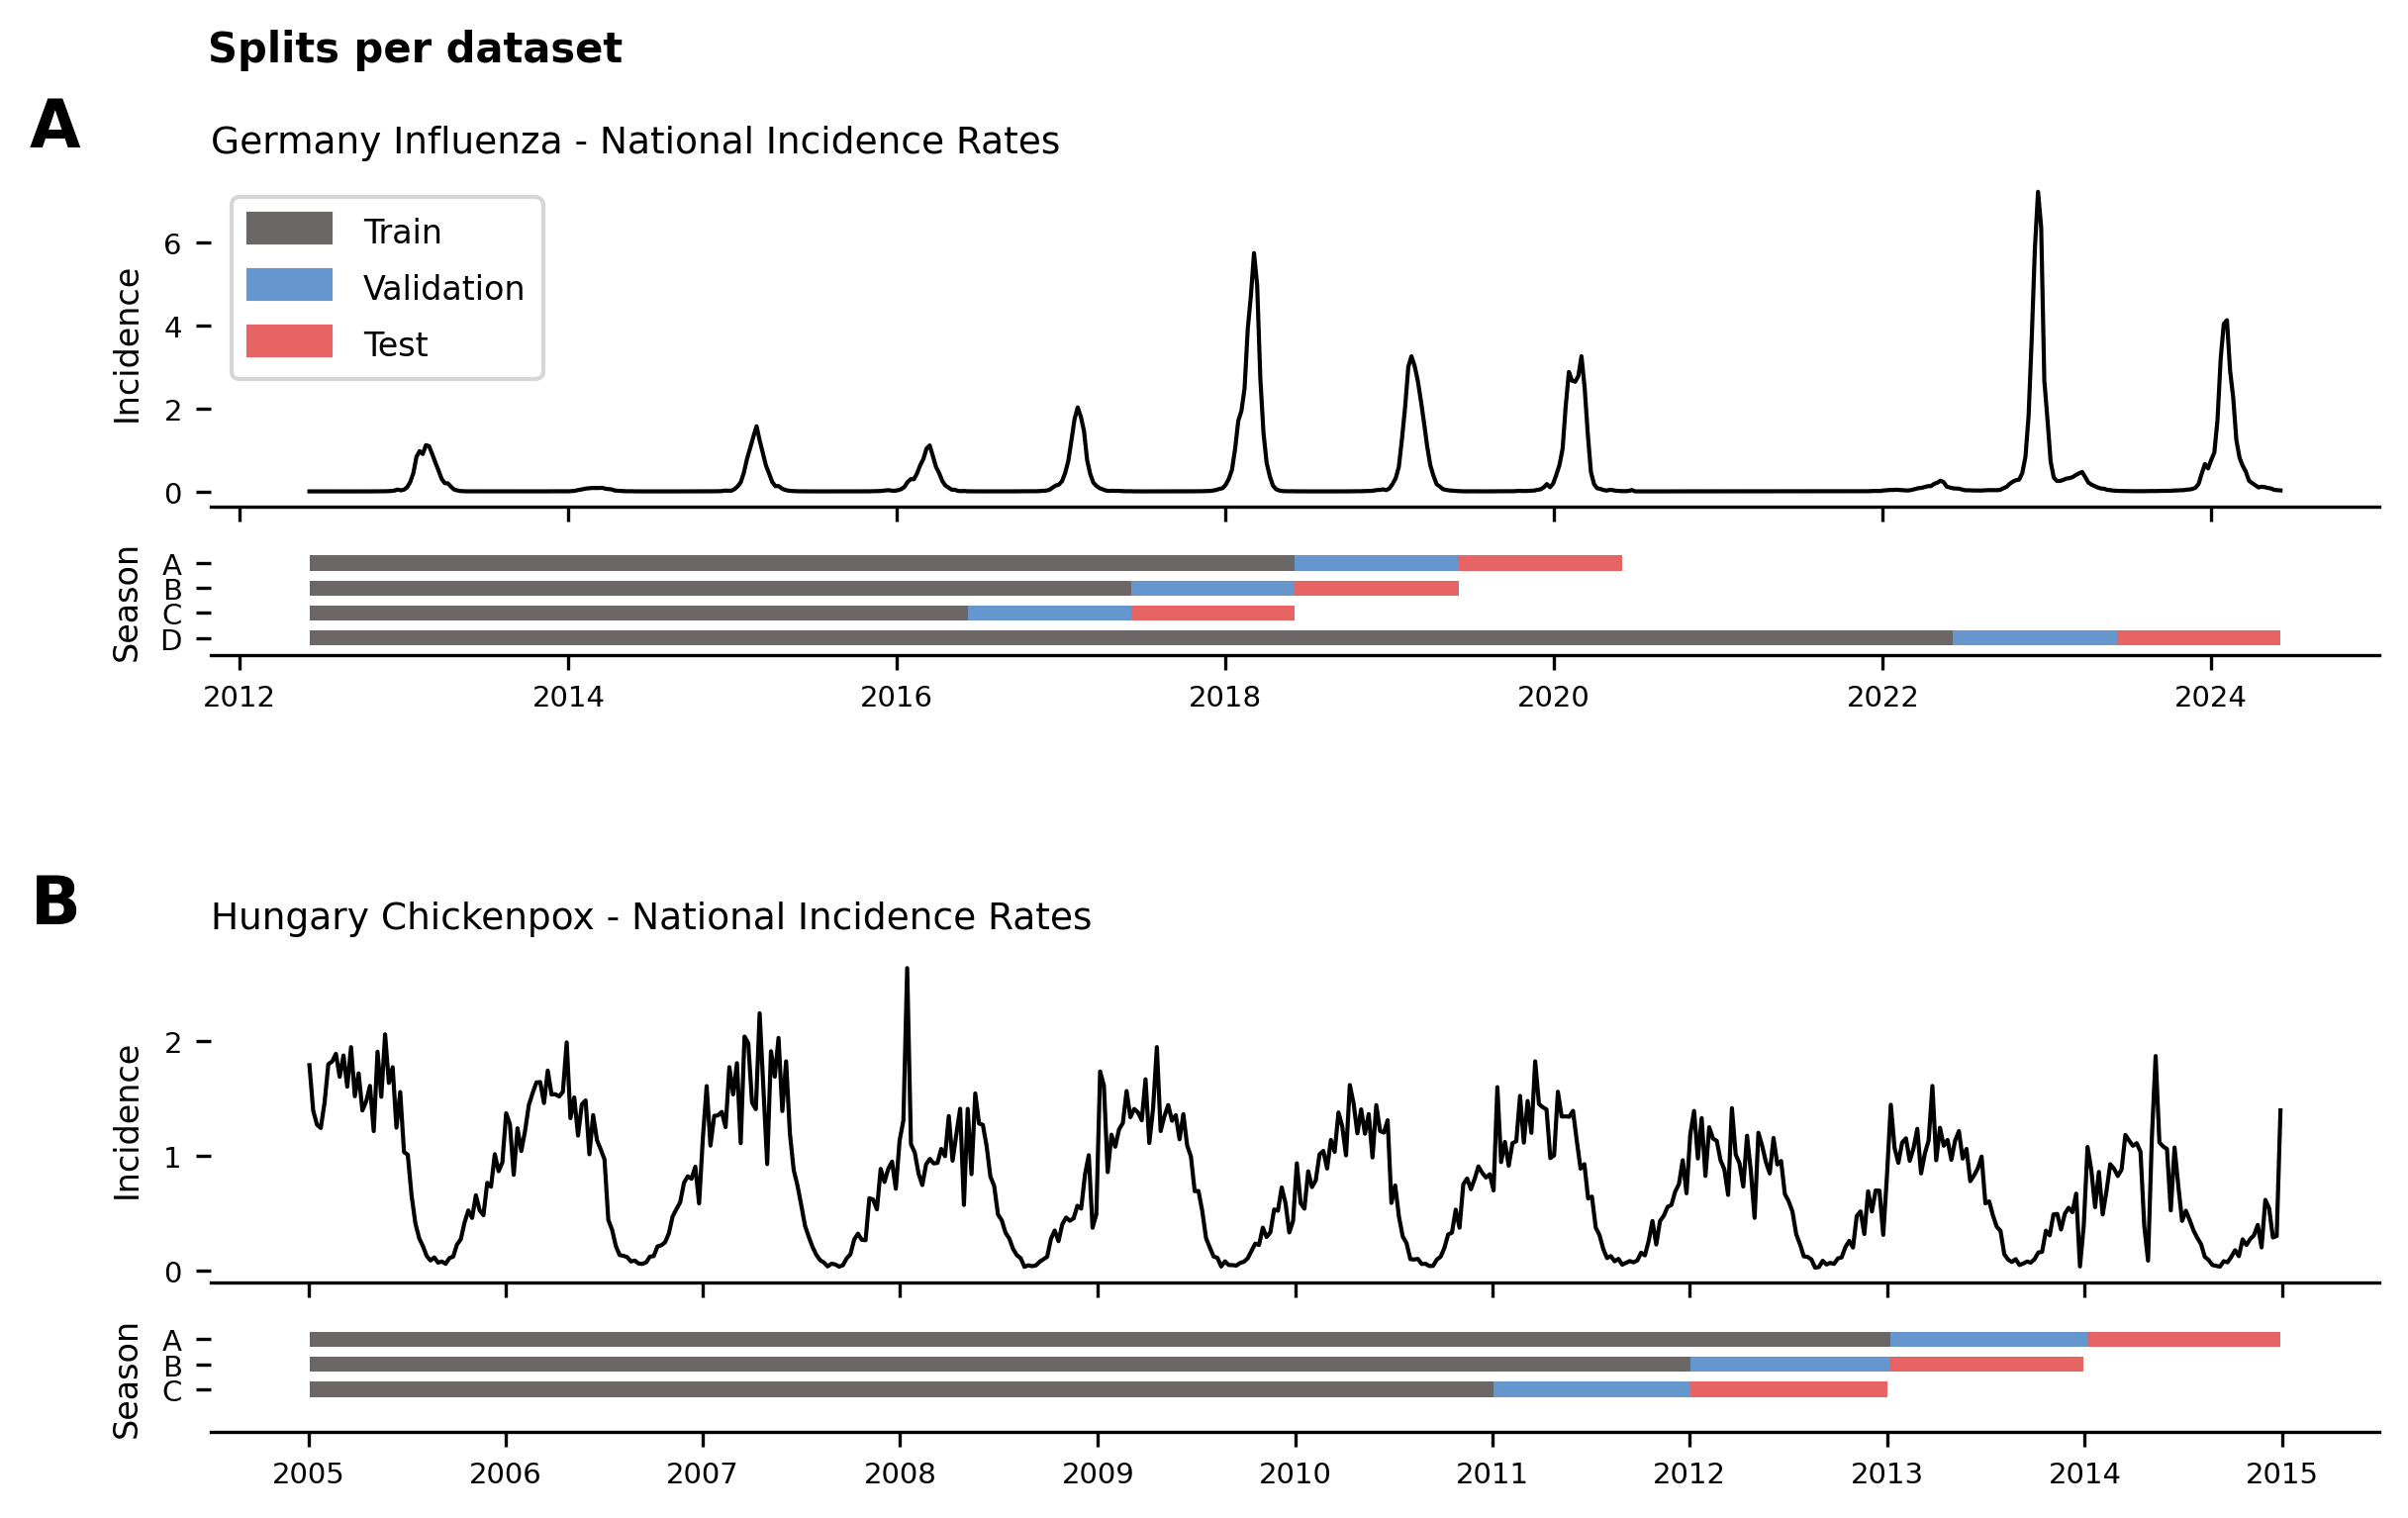

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd

# from figure_style import FigureStyle, AxesStyle, finalize_layout, align_axes_to_reference
from src.utils import PathManager
# from your_module import create_subfigure_figure2, SubFigure2Info, DateSummary, ExperimentAnalyzer

from dataclasses import dataclass 
import pandas as pd

@dataclass 
class DateSummary:
    min:        pd.Timestamp
    trainval:   pd.Timestamp
    valtest:    pd.Timestamp
    max:        pd.Timestamp

    def __repr__(self):
        return f"<{self.__class__.__name__}(min, trainval, valtest, max)>"

@dataclass
class SubFigure2Info:
    min_date: pd.Timestamp 
    max_date: pd.Timestamp 

    subexperiment_hls:  list[ExperimentAnalyzer]

    def __post_init__(self):
        self.datasplits: dict[str, DateSummary] = {}
        self.subexperiments = [chr(ord('A') + i) for i in range(len(self.subexperiment_hls))]

        for idx, exp in enumerate(self.subexperiment_hls):

            self.datasplits[self.subexperiments[idx]] = DateSummary(
                    pd.Timestamp(exp.epidataorchestrators[1].data_context.temporal_summary.min_date),
                    pd.Timestamp(exp.epidataorchestrators[1].data_context.temporal_summary.split_trainval),
                    pd.Timestamp(exp.epidataorchestrators[1].data_context.temporal_summary.split_valtest),
                    pd.Timestamp(exp.epidataorchestrators[1].data_context.temporal_summary.max_date)                    
                    )
            

        min_dates = [datesummary.min for _, datesummary in self.datasplits.items()]
        max_dates = [datesummary.max for _, datesummary in self.datasplits.items()]


        line_min_date = min(min_dates)
        line_max_date = max(max_dates)

        casedata = self.subexperiment_hls[0].epidataorchestrators[1].data_harmonized.epidata
        casedata = casedata.groupby(['timestamp']).agg({'cases':'sum','population_size':'sum'}).reset_index(drop = False)
        casedata['incidence'] = casedata['cases'] / casedata['population_size'] *  self.subexperiment_hls[0].epicfg.incidence_scalar
        casedata = casedata[casedata['timestamp']>=line_min_date]
        casedata = casedata[casedata['timestamp']<=line_max_date]

        self.global_incidence = casedata

def create_subfigure_figure2(axes: list[Axes], info: SubFigure2Info) -> None:
    colors = {
        "train" : "#6B6767",
        "val"   : "#6696CE",
        "test"  : "#E76464",
    }    

    bar_height = 0.6
    axes[1].grid()
    for i, (exp, dates) in enumerate(info.datasplits.items()):

        start       = dates.min
        train_end   = dates.trainval
        val_end     = dates.valtest
        end         = dates.max

        y = 3 - i   # A at top

        axes[1].broken_barh(
            [(mdates.date2num(start),
            mdates.date2num(train_end) - mdates.date2num(start))],
            (y - bar_height/2, bar_height),
            facecolors=colors["train"],
        )

        axes[1].broken_barh(
            [(mdates.date2num(train_end),
            mdates.date2num(val_end) - mdates.date2num(train_end))],
            (y - bar_height/2, bar_height),
            facecolors=colors["val"],
        )

        axes[1].broken_barh(
            [(mdates.date2num(val_end),
            mdates.date2num(end) - mdates.date2num(val_end))],
            (y - bar_height/2, bar_height),
            facecolors=colors["test"],
        )


    sns.lineplot(info.global_incidence, x = 'timestamp', y = 'incidence', color = 'black', ax = axes[0], linewidth = 1)
    axes[0].grid()


    handles = [
        plt.Rectangle((0, 0), 1, 1, color=colors["train"]),
        plt.Rectangle((0, 0), 1, 1, color=colors["val"]),
        plt.Rectangle((0, 0), 1, 1, color=colors["test"]),
    ]

    axes[0].legend(
        handles,
        ["Train", "Validation", "Test"],
        loc="upper left",
    )

    axes[0].spines["top"].set_visible(False)
    axes[0].spines["right"].set_visible(False)
    axes[0].spines["left"].set_visible(False)

    axes[1].set_yticks(range(4 - len(info.subexperiments), 4))
    axes[1].set_yticklabels(info.subexperiments[::-1])
    axes[1].set_ylim(-0.7, 3.7)

    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)
    axes[1].spines["left"].set_visible(False)
    axes[1].grid(axis='y', visible=False)   # or True, if you want horizontal separators between rows


# --------------------------------------------------------------------------
# Style definitions
# --------------------------------------------------------------------------

figure2_style = FigureStyle(
    figsize=(8, 5),
    suptitle="Splits per dataset",
    suptitle_args= {"x" : 0.168}
)

axes0_style = AxesStyle(
    title="Germany Influenza - National Incidence Rates",
    label_y="Incidence",
    tag="A",
    legend=True,
    ticks_x_labels=False,
)

axes1_style = AxesStyle(label_y="Season")

axes2_style = AxesStyle(
    title="Hungary Chickenpox - National Incidence Rates",
    label_y="Incidence",
    tag="B",
    ticks_x_labels=False,
)

axes3_style = AxesStyle(label_y="Season")

# --------------------------------------------------------------------------
# Build the grid
# --------------------------------------------------------------------------

fig = plt.figure(figsize=figure2_style.figsize, constrained_layout=True)
gs = fig.add_gridspec(5, 1, height_ratios=[3, 1, 1, 3, 1])

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)

spacer = fig.add_subplot(gs[2])
spacer.axis("off")

ax3 = fig.add_subplot(gs[3])
ax4 = fig.add_subplot(gs[4], sharex=ax3)

fig.align_ylabels([ax1, ax2, ax3, ax4])

# --------------------------------------------------------------------------
# 1. Plot content first, while constrained_layout is still active
# --------------------------------------------------------------------------

figureA = SubFigure2Info(pd.Timestamp("2012-01-01"), pd.Timestamp("2025-01-01"), [exp2a, exp2b, exp2c, exp2d])
figureB = SubFigure2Info(pd.Timestamp("2004-01-01"), pd.Timestamp("2025-01-01"), [exp4a, exp4b, exp4c])

create_subfigure_figure2([ax1, ax2], figureA)
create_subfigure_figure2([ax3, ax4], figureB)

# --------------------------------------------------------------------------
# 2. Apply all standardized cosmetic styling (titles/labels/tags/ticks/legend)
# --------------------------------------------------------------------------

fig, axes = finalize_layout(
    fig,
    [ax1, ax2, ax3, ax4],
    figure2_style,
    [axes0_style, axes1_style, axes2_style, axes3_style],
)

# --------------------------------------------------------------------------
# 3. Now that content + styling are final, align positions and freeze layout
#    (single call -- no more duplicated position-copy blocks)
# --------------------------------------------------------------------------

align_axes_to_reference(fig, ref_ax=ax1, other_axes=[ax2, ax3, ax4])

# --------------------------------------------------------------------------
# Save
# --------------------------------------------------------------------------

pathmanager = PathManager()

fig.savefig(pathmanager.results / "figure2.svg", bbox_inches="tight")
fig.savefig(pathmanager.results / "figure2.pdf", bbox_inches="tight")  # vector, journal-friendly
fig.savefig(pathmanager.results / "figure2.eps",bbox_inches="tight",dpi=figure2_style.dpi)

# Figure 3: RMSE vs CCC => experiment 1 A

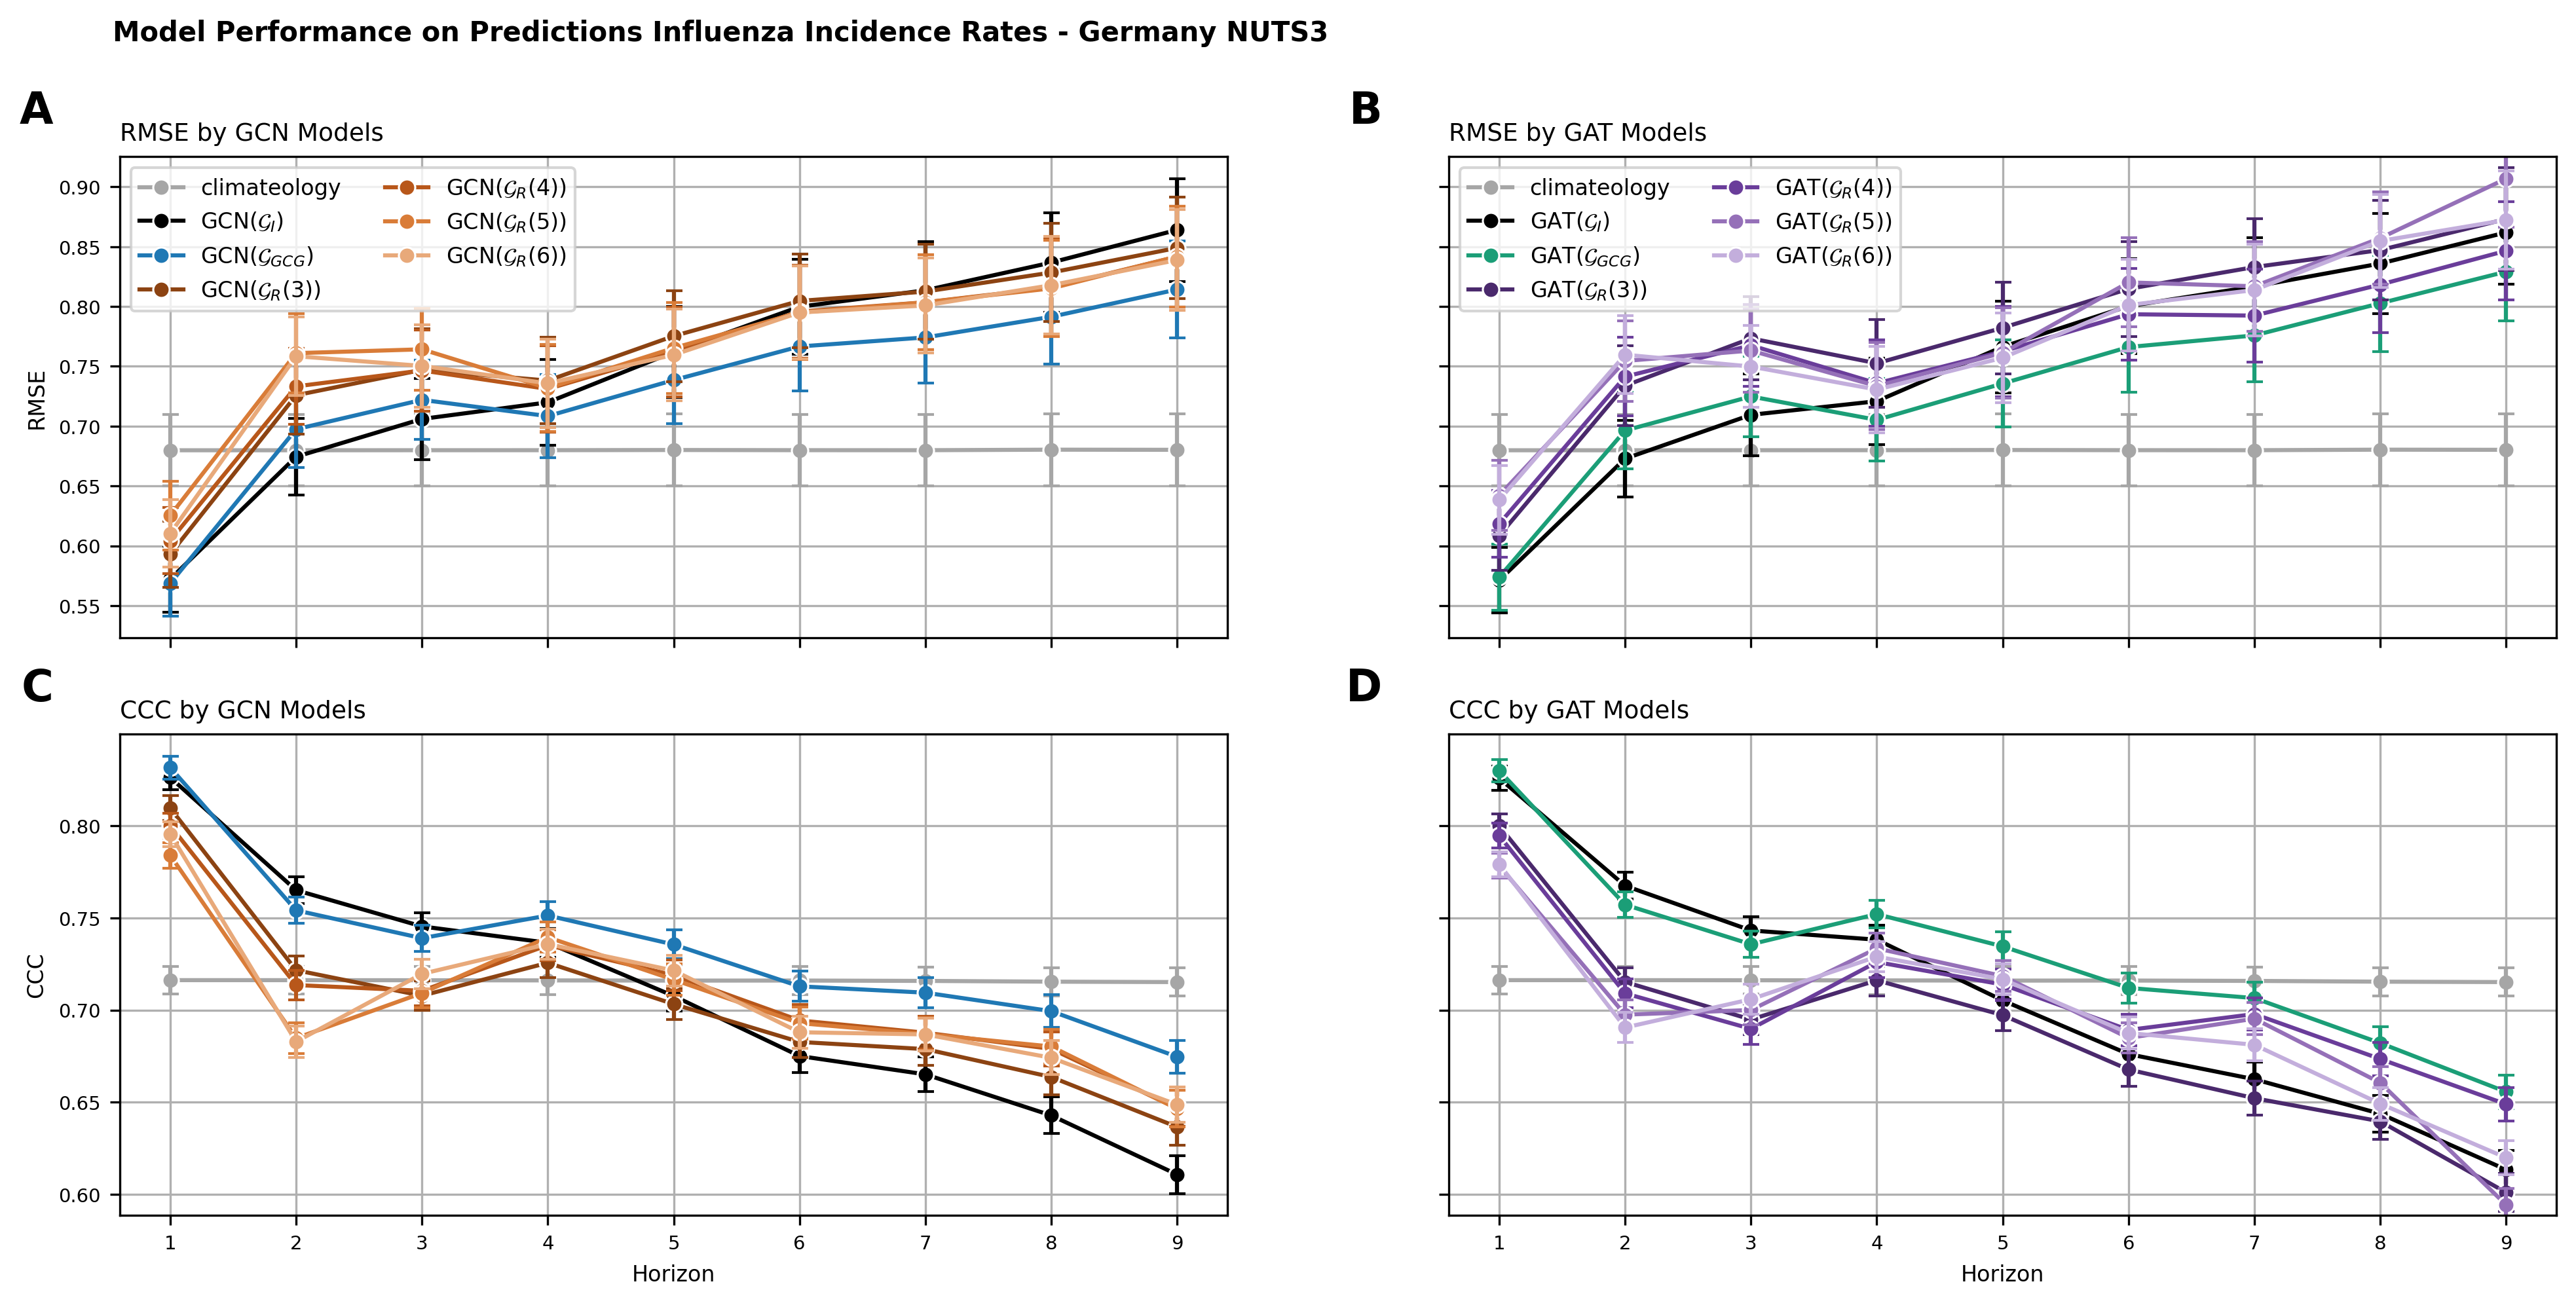

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# from figure_style import FigureStyle, AxesStyle, finalize_layout

# --------------------------------------------------------------------------
# Style definitions
# --------------------------------------------------------------------------

figure3_style = FigureStyle(
    figsize=(16, 7),
    suptitle="Model Performance on Predictions Influenza Incidence Rates - Germany NUTS3",
    suptitle_args= {"x" : 0.316}
)

top_legend_args = {"loc": "upper left", "ncols": 2}
legend_labels = {
    # gcn
    'gcngraph1' : r'GCN($\mathcal{G}_{I}$)',
    'gcngraph2' : r'GCN($\mathcal{G}_{GCG}$)',
    'gcngraph3' : r'GCN($\mathcal{G}_{R}(3)$)',
    'gcngraph4' : r'GCN($\mathcal{G}_{R}(4)$)',
    'gcngraph5' : r'GCN($\mathcal{G}_{R}(5)$)',
    'gcngraph6' : r'GCN($\mathcal{G}_{R}(6)$)',
    # gat
    'gatgraph1' : r'GAT($\mathcal{G}_{I}$)',    
    'gatgraph2' : r'GAT($\mathcal{G}_{GCG}$)',
    'gatgraph3' : r'GAT($\mathcal{G}_{R}(3)$)',
    'gatgraph4' : r'GAT($\mathcal{G}_{R}(4)$)',
    'gatgraph5' : r'GAT($\mathcal{G}_{R}(5)$)',
    'gatgraph6' : r'GAT($\mathcal{G}_{R}(6)$)',
}
# Row 0 = RMSE, Row 1 = CCC. Column 0 = gcn, Column 1 = gat.
axes0_style = AxesStyle(  # top-left: RMSE / gcn
    tag="A",
    title = 'RMSE by GCN Models',
    label_y="RMSE",
    ticks_x_labels=False,   # shared with bottom row -> redundant
    legend=True,
    legend_args=top_legend_args,
    legend_labels = legend_labels,
    show_grid=True,
)
axes1_style = AxesStyle(  # top-right: RMSE / gat
    tag="B",
    title = 'RMSE by GAT Models',    
    ticks_x_labels=False,
    ticks_y_labels=False,   # shared with left column (sharey='row') -> redundant
    legend=True,
    legend_args=top_legend_args,
    legend_labels = legend_labels,    
    show_grid=True
)
axes2_style = AxesStyle(  # bottom-left: CCC / gcn
    tag="C",
    title = 'CCC by GCN Models',    
    label_y="CCC",
    legend=False,
    show_grid=True,
    label_x = 'Horizon'
)
axes3_style = AxesStyle(  # bottom-right: CCC / gat
    tag="D",
    title = 'CCC by GAT Models',    
    ticks_y_labels=False,
    legend=False,
    show_grid=True,
    label_x = 'Horizon'
)

# --------------------------------------------------------------------------
# Data setup (unchanged from your original)
# --------------------------------------------------------------------------

sel = exp1a
sel._set_modelcolors()

baselines = True
ylim = None
graph = None
baseline_types = ["climateology"]

model_types = ["gcn", "gat"]
graphs = [graph] if graph is not None else ["graph1", "graph2", "graph3", "graph4", "graph5", "graph6"]
models = [x + y for x in model_types for y in graphs]
models = baseline_types + models

# --------------------------------------------------------------------------
# Build the grid + plot content first
# --------------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=figure3_style.figsize, sharex=True, sharey="row")
axes = list(axes.flatten())

for idx, ax in enumerate(axes):
    metric = "rmse" if idx < 2 else "ccc"
    model_type = model_types[0] if idx in (0, 2) else model_types[1]

    df = sel.summarize_absolute_metric(metric)
    for ml in models:
        if ml.startswith(model_type) or ml in baseline_types:
            subset = df[df["model"] == ml]
            sns.lineplot(subset, x="hl", y="mean", c=sel.model_colors[ml], ax=ax, marker="o", label=ml)
            ax.errorbar(
                x=subset["hl"],
                y=subset["mean"],
                yerr=subset["sem"],
                fmt="none",
                capsize=3,
                color=sel.model_colors[ml],
            )

    ax.set_ylim(ylim)

# --------------------------------------------------------------------------
# Apply standardized styling -- replaces the manual tag-text and legend loops
# --------------------------------------------------------------------------

fig, axes = finalize_layout(
    fig,
    axes,
    figure3_style,
    [axes0_style, axes1_style, axes2_style, axes3_style],
)

# Regular subplots() grid with sharex/sharey is already aligned -- no need
# for align_axes_to_reference() here (that was only for figure 2's
# independently-gridded rows of mismatched height).

# --------------------------------------------------------------------------
# Save
# --------------------------------------------------------------------------

# from src.utils import PathManager
pathmanager = PathManager()
fig.savefig(pathmanager.results / "figure3.svg", bbox_inches="tight", dpi=figure3_style.dpi)
fig.savefig(pathmanager.results / "figure3.pdf", bbox_inches="tight", dpi=figure3_style.dpi)
fig.savefig(pathmanager.results / "figure3.eps",bbox_inches="tight",dpi=figure3_style.dpi)

# Figure 4: CCC decomp => experiment 1 A

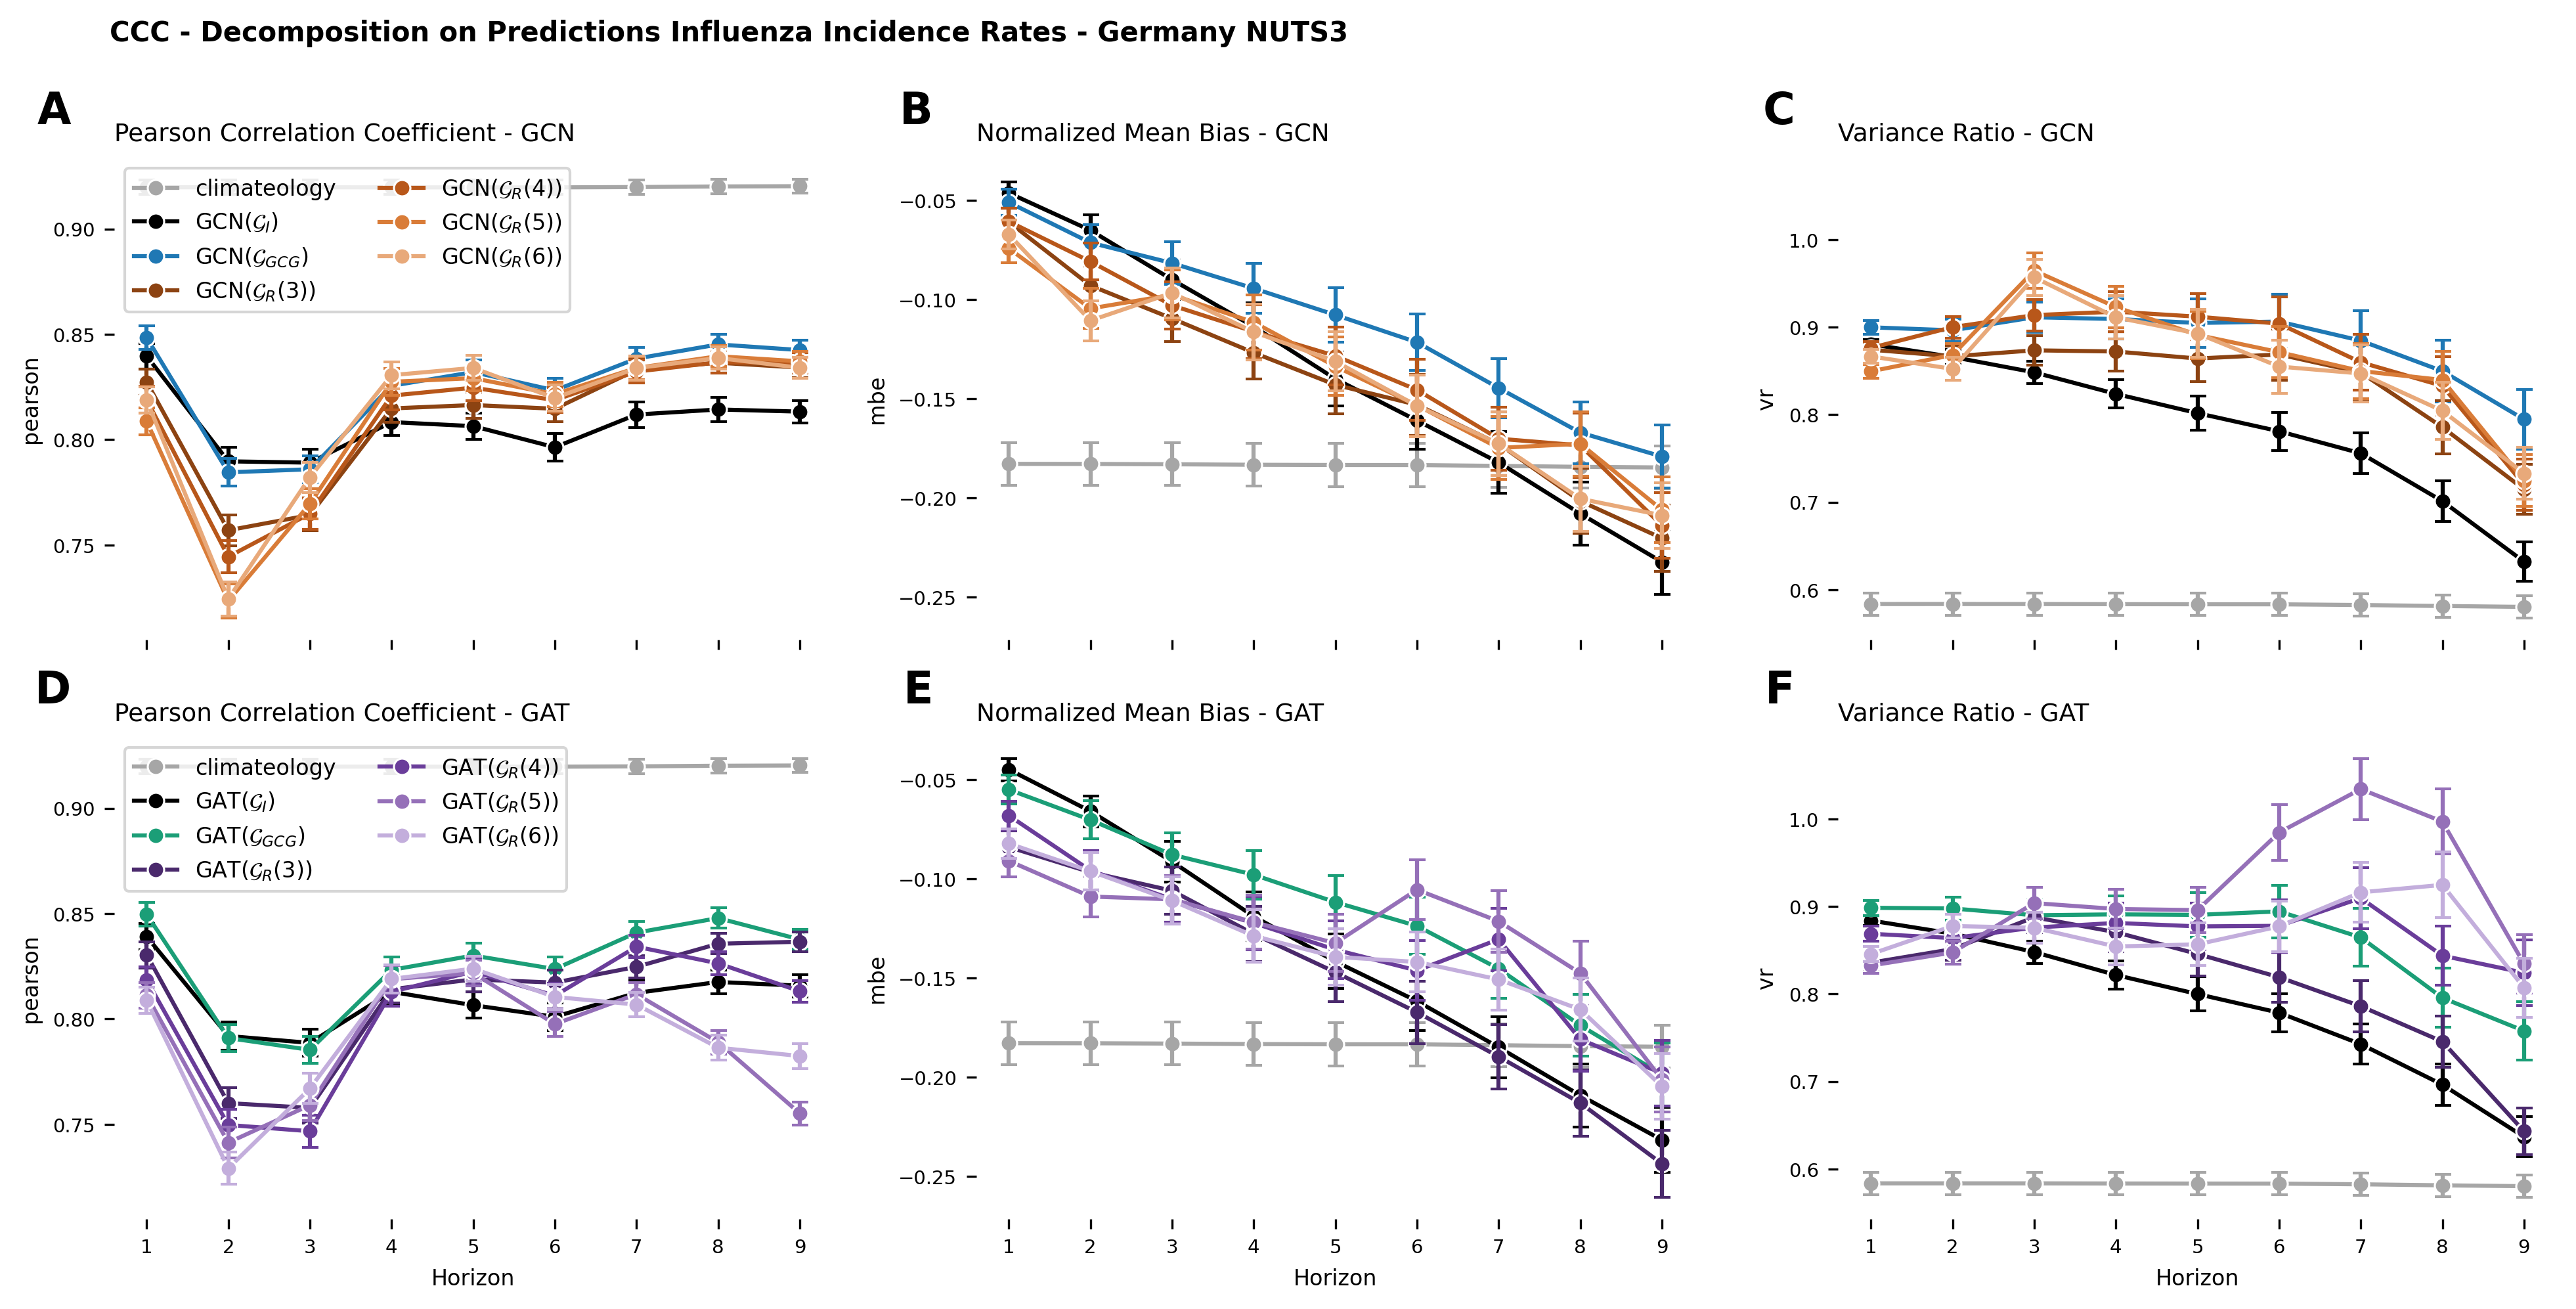

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# from figure_style import FigureStyle, AxesStyle, finalize_layout

# NOTE: model_types and baseline_types are assumed already defined earlier
# in the notebook (same as figure 3's setup): model_types = ['gcn', 'gat'],
# baseline_types = ['climateology']. Re-define them here if this runs standalone.

# --------------------------------------------------------------------------
# Style definitions
# --------------------------------------------------------------------------

figure4_style = FigureStyle(
    figsize=(16, 7),
    suptitle="CCC - Decomposition on Predictions Influenza Incidence Rates - Germany NUTS3",
    suptitle_args= {"x" : 0.32}    
)

metrics         = ["pearson", "mbe", "vr"]
metrics_names   = ["Pearson Correlation Coefficient",
                   "Normalized Mean Bias",
                   "Variance Ratio"]
tags = ["A", "B", "C", "D", "E", "F"]

legend_args = {"ncols": 2, "title_fontproperties": {"weight": "bold"},'loc':'upper left'}
legend_labels = {
    # gcn
    'gcngraph1' : r'GCN($\mathcal{G}_{I}$)',
    'gcngraph2' : r'GCN($\mathcal{G}_{GCG}$)',
    'gcngraph3' : r'GCN($\mathcal{G}_{R}(3)$)',
    'gcngraph4' : r'GCN($\mathcal{G}_{R}(4)$)',
    'gcngraph5' : r'GCN($\mathcal{G}_{R}(5)$)',
    'gcngraph6' : r'GCN($\mathcal{G}_{R}(6)$)',
    # gat
    'gatgraph1' : r'GAT($\mathcal{G}_{I}$)',    
    'gatgraph2' : r'GAT($\mathcal{G}_{GCG}$)',
    'gatgraph3' : r'GAT($\mathcal{G}_{R}(3)$)',
    'gatgraph4' : r'GAT($\mathcal{G}_{R}(4)$)',
    'gatgraph5' : r'GAT($\mathcal{G}_{R}(5)$)',
    'gatgraph6' : r'GAT($\mathcal{G}_{R}(6)$)',
}
axes_styles = []
for idx in range(6):
    row = idx // 3
    col = idx % 3
    axes_styles.append(
        AxesStyle(
            tag=tags[idx],
            label_y=metrics[col],
            label_x="Horizon" if row == 1 else None,
            ticks_x_labels=(row == 1),   # only bottom row shows x-tick numbers
            legend=(col == 0),           # both rows' left column get a legend
            legend_args=legend_args if col == 0 else {},
            legend_labels=legend_labels if col == 0 else {}, 
            show_grid=False,
            title = f"{metrics_names[col]} - {model_types[row].upper()}",
            spines = False,
        )
    )

# --------------------------------------------------------------------------
# Build the grid + plot content first
# --------------------------------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=figure4_style.figsize, sharex=True, sharey="col")
axes = list(axes.flatten())

exp1a._set_modelcolors()

for idx, ax in enumerate(axes):
    row = idx // 3
    col = idx % 3
    metric = metrics[col]
    model_type = model_types[row]

    summary = exp1a.summarize_absolute_metric(metric)

    for ml in summary["model"].unique():
        if ml.startswith(model_type) or ml in baseline_types:
            subset = summary[summary["model"] == ml]
            sns.lineplot(subset, x="hl", y="mean", c=exp1a.model_colors[ml], ax=ax, marker="o", label=ml)
            ax.errorbar(
                x=subset["hl"],
                y=subset["mean"],
                yerr=subset["sem"],
                fmt="none",
                capsize=3,
                color=exp1a.model_colors[ml],
            )

# --------------------------------------------------------------------------
# Apply standardized styling -- replaces the manual ylabel/xlabel/tag/legend code
# --------------------------------------------------------------------------

fig, axes = finalize_layout(
    fig,
    axes,
    figure4_style,
    axes_styles,
)

# Regular subplots() grid -- already aligned, no align_axes_to_reference() needed.

# --------------------------------------------------------------------------
# Save
# --------------------------------------------------------------------------

# from src.utils import PathManager
pathmanager = PathManager()
fig.savefig(pathmanager.results / "figure4.svg", bbox_inches="tight", dpi=figure4_style.dpi)
fig.savefig(pathmanager.results / "figure4.pdf", bbox_inches="tight", dpi=figure4_style.dpi)
fig.savefig(pathmanager.results / "figure4.eps",bbox_inches="tight",dpi=figure4_style.dpi)

# Figure 5: Graph advantage => experiment 1A/2A/3A/4A

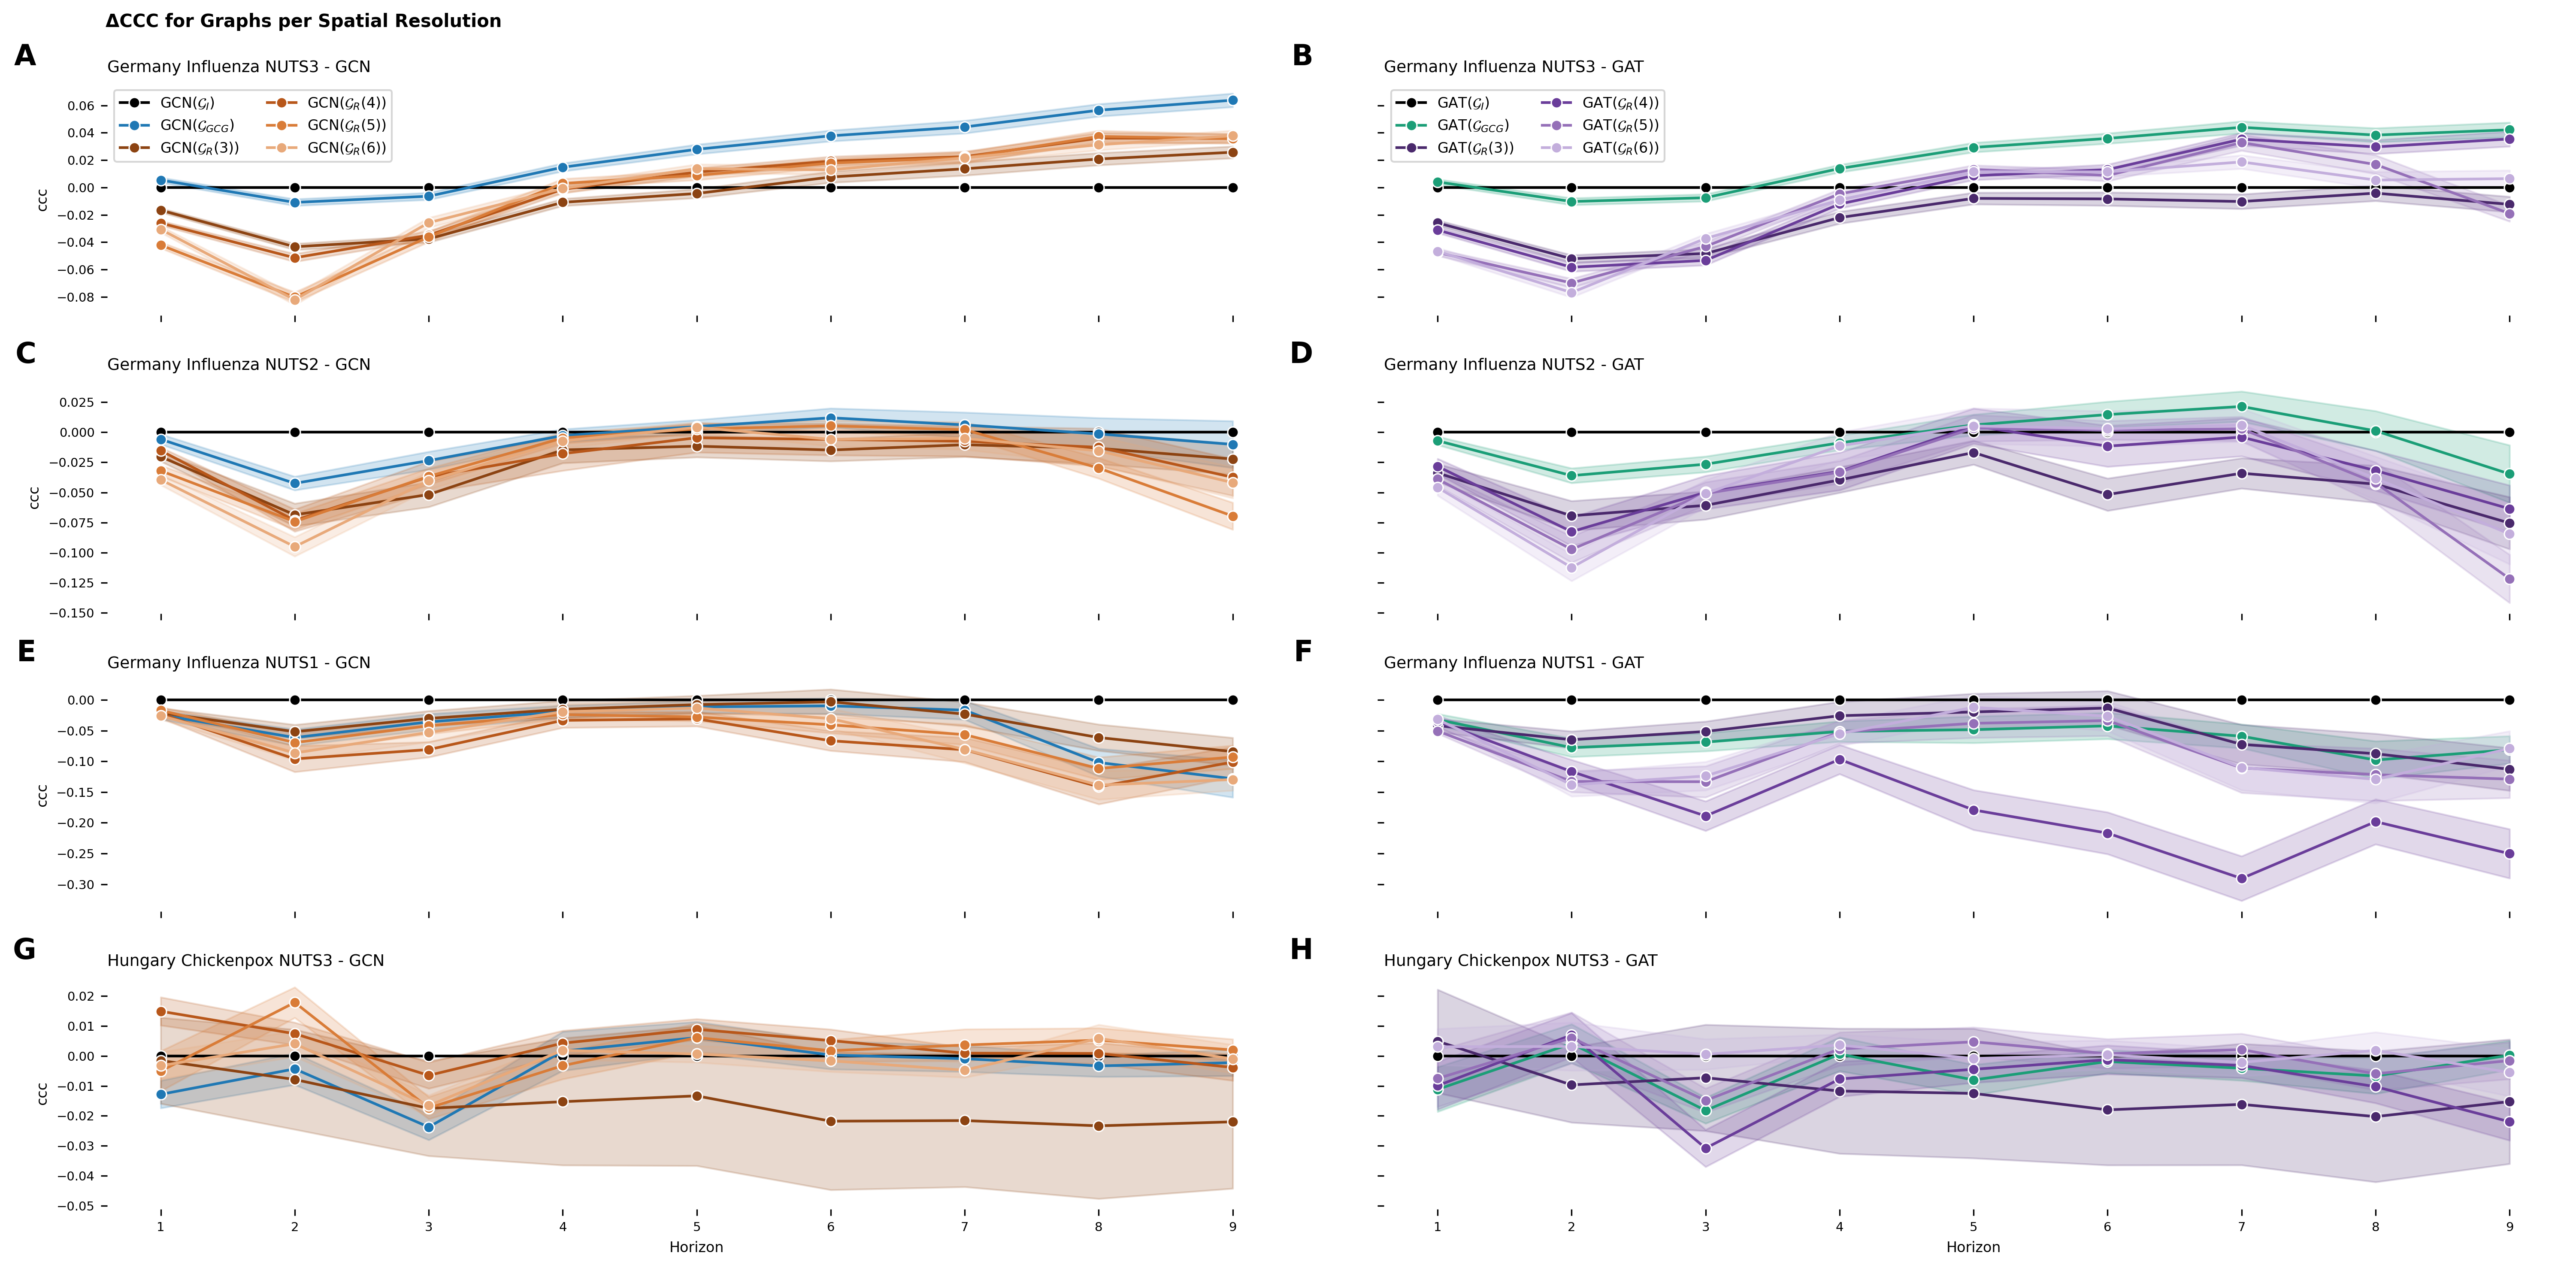

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# from figure_style import FigureStyle, AxesStyle, finalize_layout

# --------------------------------------------------------------------------
# Style definitions
# --------------------------------------------------------------------------

figure5_style = FigureStyle(
    figsize=(20, 10),
    suptitle= rf"ΔCCC for Graphs per Spatial Resolution",
    suptitle_args={"x":0.115}
)

modeltypes  = ["gcn", "gat"]
experiments = [exp1a, exp2a, exp3a, exp4a]
metric      = "ccc"

tags    = ["A", "B", "C", "D", "E", "F", "G", "H"]
titles  = [
        "Germany Influenza NUTS3 - GCN",
        "Germany Influenza NUTS3 - GAT",
        "Germany Influenza NUTS2 - GCN",
        "Germany Influenza NUTS2 - GAT",
        "Germany Influenza NUTS1 - GCN",
        "Germany Influenza NUTS1 - GAT",
        "Hungary Chickenpox NUTS3 - GCN",
        "Hungary Chickenpox NUTS3 - GAT",                                                
]
n_rows = len(experiments)
last_row = n_rows - 1

legend_args = {"ncols": 2, "title_fontproperties": {"weight": "bold"}, 'loc' : 'upper left'}
legend_labels = {
    # gcn
    'gcngraph1' : r'GCN($\mathcal{G}_{I}$)',
    'gcngraph2' : r'GCN($\mathcal{G}_{GCG}$)',
    'gcngraph3' : r'GCN($\mathcal{G}_{R}(3)$)',
    'gcngraph4' : r'GCN($\mathcal{G}_{R}(4)$)',
    'gcngraph5' : r'GCN($\mathcal{G}_{R}(5)$)',
    'gcngraph6' : r'GCN($\mathcal{G}_{R}(6)$)',
    # gat
    'gatgraph1' : r'GAT($\mathcal{G}_{I}$)',    
    'gatgraph2' : r'GAT($\mathcal{G}_{GCG}$)',
    'gatgraph3' : r'GAT($\mathcal{G}_{R}(3)$)',
    'gatgraph4' : r'GAT($\mathcal{G}_{R}(4)$)',
    'gatgraph5' : r'GAT($\mathcal{G}_{R}(5)$)',
    'gatgraph6' : r'GAT($\mathcal{G}_{R}(6)$)',
}

axes_styles = []
for idx in range(n_rows * 2):
    row = idx // 2
    col = idx % 2
    axes_styles.append(
        AxesStyle(
            tag=tags[idx],
            title = titles[idx],
            label_y=metric if col == 0 else None,
            label_x="Horizon" if row == last_row else None,
            ticks_x_labels=(row == last_row),  # sharex=True -> only bottom row
            ticks_y_labels=(col == 0),         # sharey='row' -> only left column
            legend=(row == 0),
            legend_args=legend_args if row == 0 else {},
            legend_labels=legend_labels if row == 0 else {},            
            show_grid=False,
            spines = False
        )
    )

# --------------------------------------------------------------------------
# Data setup
# --------------------------------------------------------------------------

for experiment in experiments:
    experiment._set_modelcolors()

# --------------------------------------------------------------------------
# Build the grid + plot content first
# --------------------------------------------------------------------------

fig, axes = plt.subplots(n_rows, 2, figsize=figure5_style.figsize, sharex=True, sharey="row")
axes = list(axes.flatten())

for idx, ax in enumerate(axes):
    row = idx // 2
    col = idx % 2
    experiment = experiments[row]
    model_type = modeltypes[col]

    df1, df2    = experiment.summarize_graph_advantage(metric, model_type)
    graphmodels = list(df1["model"].unique())
    graphmodels = [gm for gm in graphmodels if gm.startswith(model_type)]
    baseline    = f"{model_type}graph1"

    for ml in df1["model"].unique():
        subset = df1[df1["model"] == ml]
        sns.lineplot(subset, x="hl", y="mean", c=experiment.model_colors[ml], ax=ax, marker="o", label=ml)
        ax.fill_between(
            x=subset["hl"],
            y1=subset["mean"] - subset["sem"],
            y2=subset["mean"] + subset["sem"],
            color=experiment.model_colors[ml],
            alpha=0.2,
        )

# --------------------------------------------------------------------------
# Apply standardized styling -- replaces the manual ylabel/xlabel/tag/legend code
# --------------------------------------------------------------------------

fig, axes = finalize_layout(
    fig,
    axes,
    figure5_style,
    axes_styles,
)

fig.tight_layout()

# Regular subplots() grid -- already aligned, no align_axes_to_reference() needed.

# --------------------------------------------------------------------------
# Save
# --------------------------------------------------------------------------

# from src.utils import PathManager
# pathmanager = PathManager()
fig.savefig(pathmanager.results / "figure5.svg", bbox_inches="tight", dpi=figure5_style.dpi)
fig.savefig(pathmanager.results / "figure5.pdf", bbox_inches="tight", dpi=figure5_style.dpi)
fig.savefig(pathmanager.results / "figure5.eps",bbox_inches="tight",dpi=figure5_style.dpi)

# Figure 6: Moran's

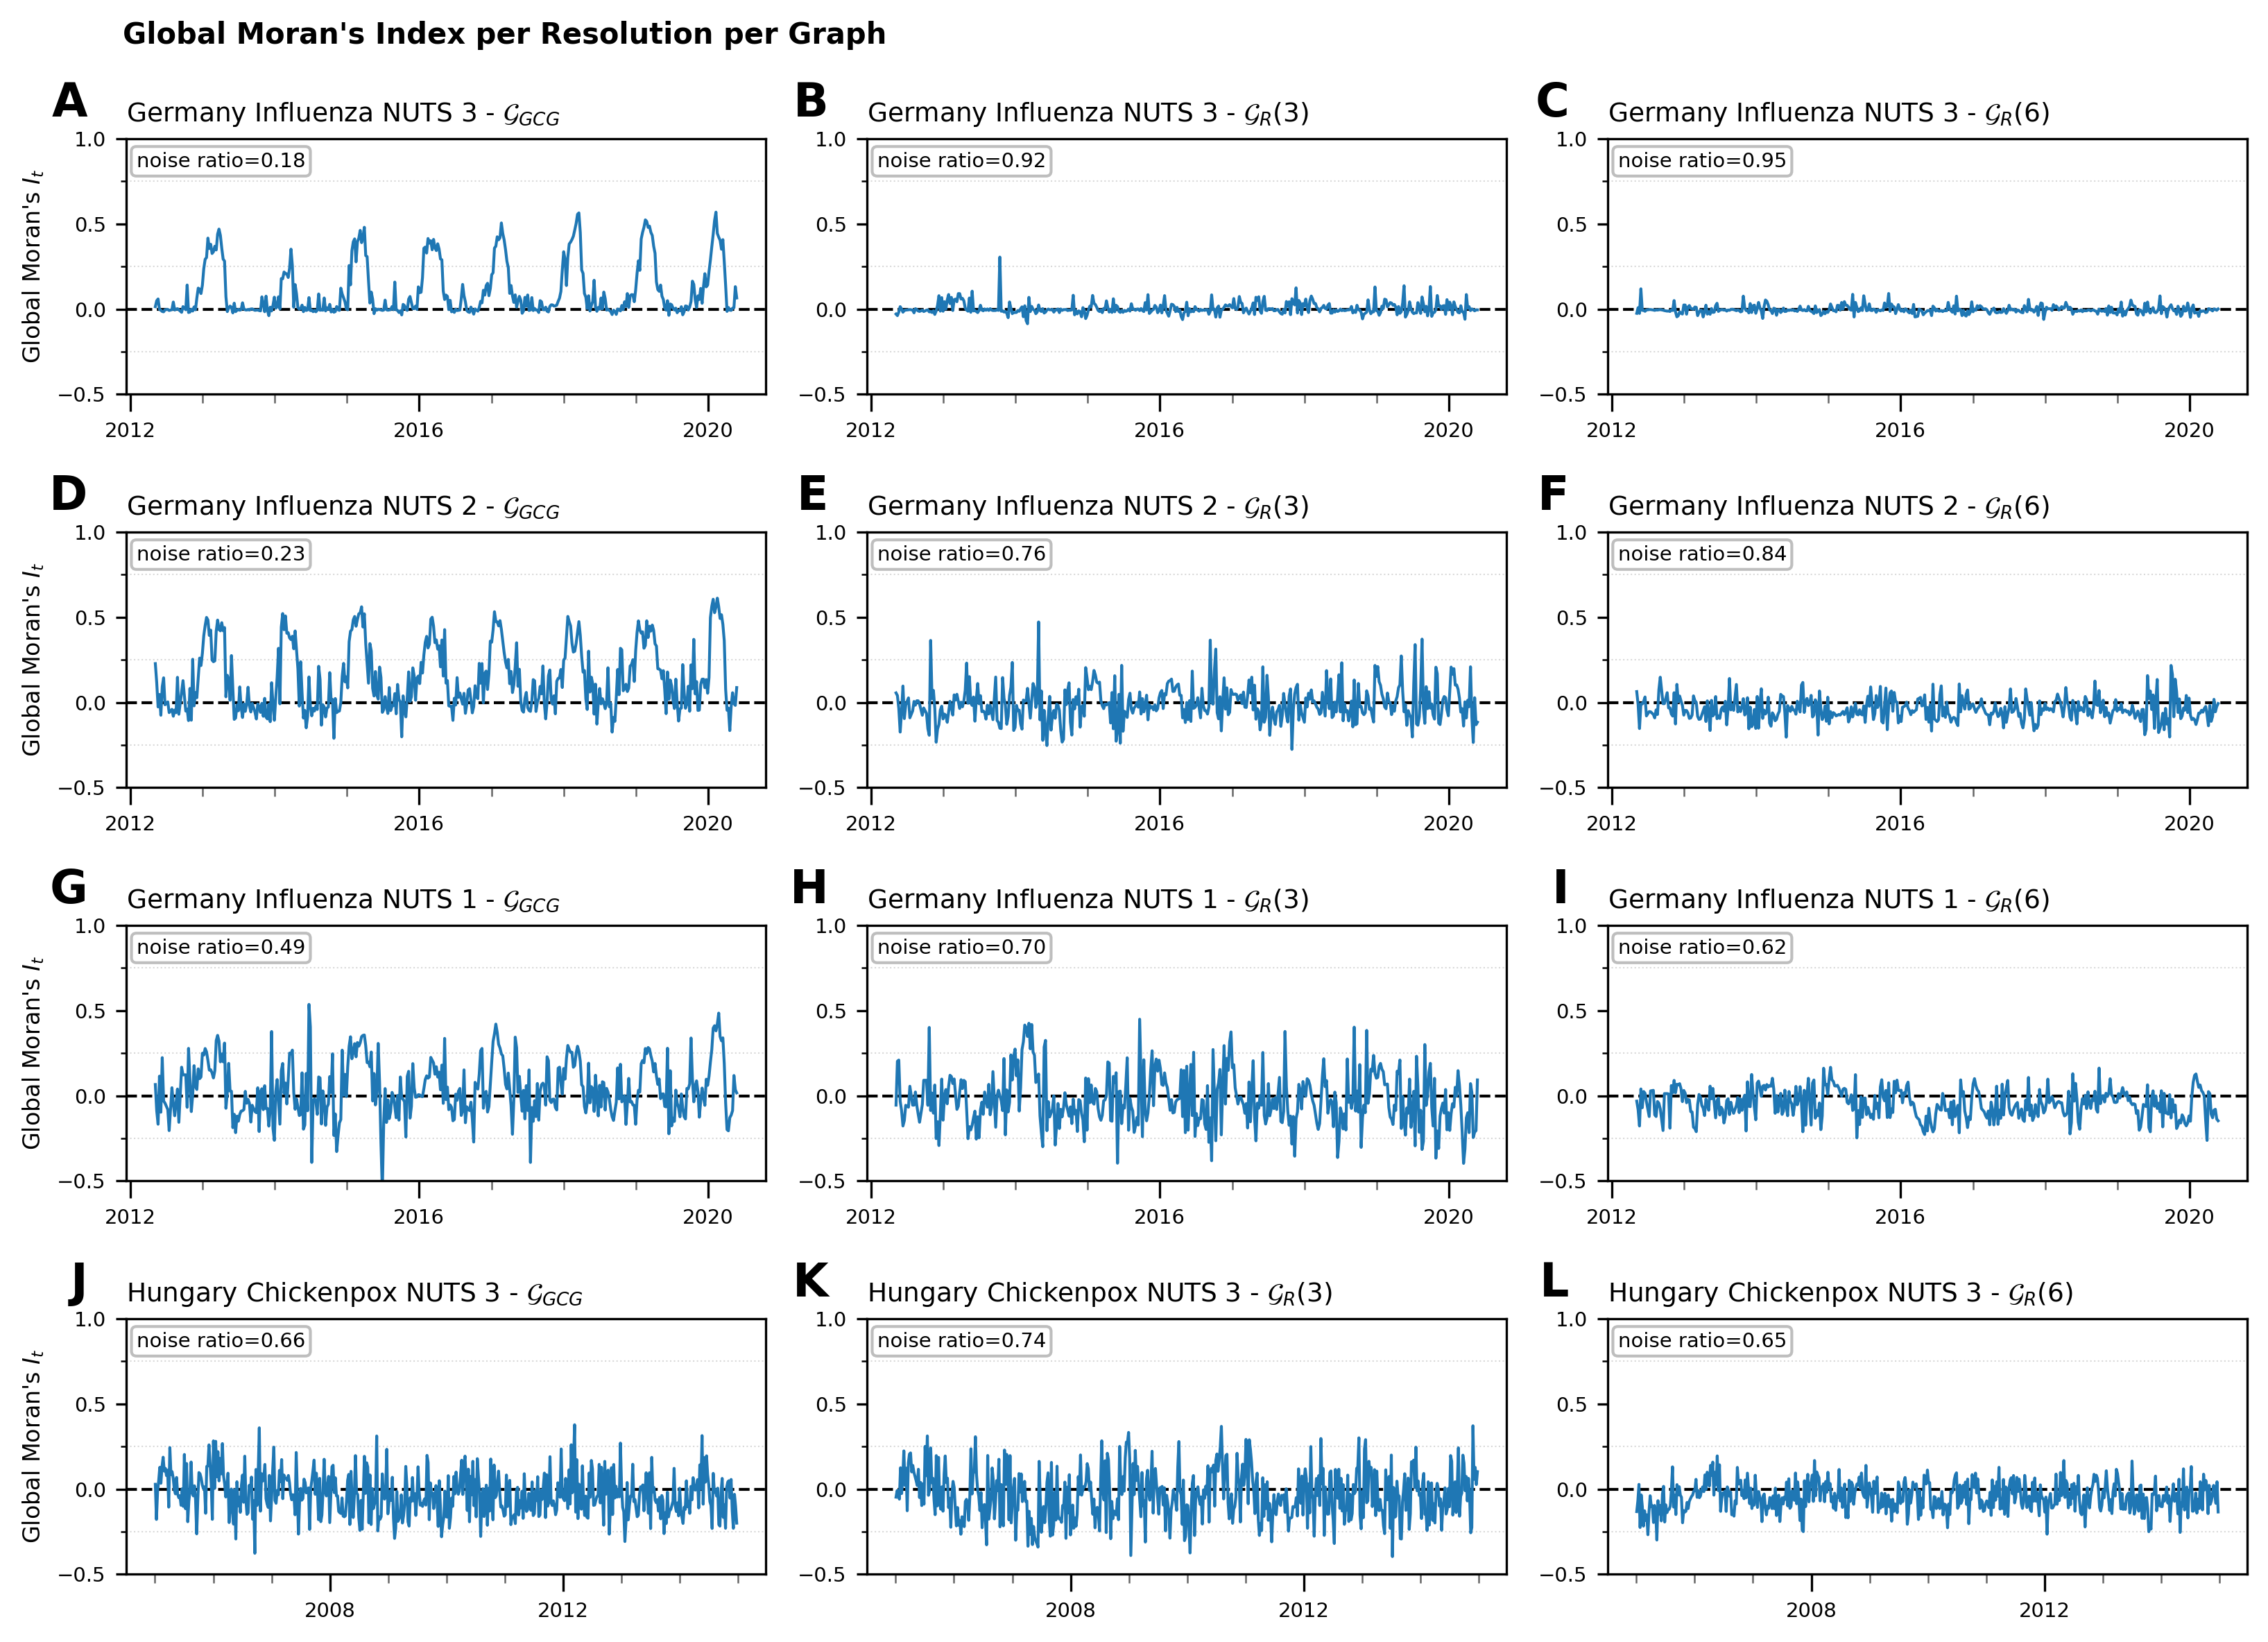

In [38]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import seaborn as sns

import numpy as np
import pandas as pd
from statsmodels.tsa.seasonal import STL

# from figure_style import FigureStyle, AxesStyle, finalize_layout


# --------------------------------------------------------------------------
# Data helper functions (unchanged)
# --------------------------------------------------------------------------

def noise_ratio(df, value_col='global_morans_i', time_col='timestamp', freq='W', period=52):
    df = df[[time_col, value_col]].copy()
    df = df.set_index(time_col).sort_index()

    # 1. Force a regular time index (fills gaps with NaN)
    df = df.resample(freq).mean()

    # 2. Interpolate any NaNs (missing timestamps or dropped values)
    df[value_col] = df[value_col].interpolate(method='time').ffill().bfill()

    # sanity check -- this should be 0 before going into STL
    assert df[value_col].isna().sum() == 0, "Still have NaNs after interpolation"

    stl = STL(df[value_col], period=period, robust=True).fit()

    resid_var = stl.resid.var()
    total_var = df[value_col].var()
    seasonal_var = stl.seasonal.var()

    return {
        'noise_ratio': resid_var / total_var,
        'seasonal_strength': max(0, 1 - resid_var / (stl.seasonal + stl.resid).var()),
        'snr_db': 10 * np.log10(seasonal_var / resid_var)
    }


def estimate_temporal_persistence(X: np.ndarray):
    """
    This estimates node-specific AR(1) where
    x_{t, i} = \\alpha x_{t-1, i} + \\epsilon_t

    here AR(1) is thus alpha.
    """
    X_prev = X[:, :-1]
    X_curr = X[:, 1:]

    num = np.sum(X_curr * X_prev, axis=1)
    den = np.sum(X_prev ** 2, axis=1) + 1e-12

    alpha = num / den
    return alpha


def estimate_temporal_residual(df: pd.DataFrame):
    X = df.pivot(index="node", columns="timestamp", values="incidence")
    X = X.sort_index(axis=0).sort_index(axis=1)

    X_np = X.to_numpy()

    alpha = estimate_temporal_persistence(X_np)

    X_prev = X_np[:, :-1]
    X_curr = X_np[:, 1:]

    eps = X_curr - alpha[:, None] * X_prev

    residuals_df = (
        pd.DataFrame(eps)
        .stack()
        .reset_index()
    )
    residuals_df.columns = ["node", "timestep_index", "residual"]
    timestamps = X.columns[1:]  # because AR(1) drops t=0
    residuals_df["timestamp"] = residuals_df["timestep_index"].map(
        dict(enumerate(timestamps))
    )

    return residuals_df


# --------------------------------------------------------------------------
# Style definitions
# --------------------------------------------------------------------------

figure6_style = FigureStyle(
    figsize=(11, 8),
    suptitle="Global Moran's Index per Resolution per Graph",
    suptitle_args={'x':0.225}
)

experiments = [exp1a, exp2a, exp3a, exp4a]
graphs      = ['graph2', 'graph3', 'graph6']
settings    = ['Germany Influenza NUTS 3',
               'Germany Influenza NUTS 2',
               'Germany Influenza NUTS 1',
               'Hungary Chickenpox NUTS 3']

n_rows = len(experiments)
n_cols = len(graphs)
tags = [chr(ord('A') + i) for i in range(n_rows * n_cols)]

axes_styles = [AxesStyle(tag=tags[idx], show_grid=False, title = f"{settings[idx // 3]} - {graph_dict[graphs[idx% 3]]}", label_y=r"Global Moran's $I_t$" if idx % 3 == 0 else None) for idx in range(n_rows * n_cols)]

# --------------------------------------------------------------------------
# Build the grid + plot content
# --------------------------------------------------------------------------

fig, axes = plt.subplots(n_rows, n_cols, figsize=figure6_style.figsize)
axes = list(axes.flatten())

for idx, ax in enumerate(axes):
    row = idx // n_cols
    col = idx % n_cols

    exp = experiments[row]
    graph = graphs[col]

    entire_ts = exp.epidataorchestrators[1].data_final.data_denorm[
        ['timestamp', 'node', 'incidence_lag0']
    ].rename(columns={'incidence_lag0': 'incidence'})
    entire_ts_rd = estimate_temporal_residual(entire_ts)

    ax.axhline(0, color='k', ls='--',linewidth = 1)

    adj_matrix = exp._get_dlm('gcn', 1, graph).graph._get_adjacency_matrix().cpu().numpy()
    global_m   = exp.global_morans_i_timeseries(entire_ts, adj_matrix)

    nr_inc = noise_ratio(global_m)['noise_ratio']

    sns.lineplot(global_m, x='timestamp', y='global_morans_i', ax=ax, linewidth = 1)

    ax.text(
        0.28, 0.95,
        f"noise ratio={nr_inc:.2f}",
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=7,
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='0.7', alpha=0.85)
    )

    ax.set_ylim([-0.5, 1.0])

    # X axis: major gridlines + labels every 4 years, minor ticks every year (no labels)
    ax.xaxis.set_major_locator(mdates.YearLocator(4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_minor_locator(mdates.YearLocator(1))

    ax.tick_params(axis='x', which='minor', length=3, color='0.4')
    ax.tick_params(axis='x', which='major', length=6)

    # Y axis: labels every 0.5, minor gridlines every 0.25
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))

    # Grid (single consolidated pass -- the earlier draft had a duplicate,
    # immediately-overridden major-x grid() call before this one; removed)
    ax.grid(which="major", axis="x", color='gray', linewidth=0.8, alpha=0.7)
    ax.grid(which="major", axis="y", color='gray', linewidth=0.8, alpha=0.7)
    ax.grid(which="minor", axis="y", color='gray', linewidth=0.5, alpha=0.3, linestyle=':')

# --------------------------------------------------------------------------
# Apply standardized styling -- replaces the manual tag loop and the
# labelsize=14 override (now uses the paper-wide global_cfg.tick_size)
# --------------------------------------------------------------------------

fig, axes = finalize_layout(
    fig,
    axes,
    figure6_style,
    axes_styles,
)

plt.tight_layout()

# --------------------------------------------------------------------------
# Save
# --------------------------------------------------------------------------

# from src.utils import PathManager
# pathmanager = PathManager()
fig.savefig(pathmanager.results / "figure6.svg", bbox_inches="tight", dpi=figure6_style.dpi)
fig.savefig(pathmanager.results / "figure6.pdf", bbox_inches="tight", dpi=figure6_style.dpi)
fig.savefig(pathmanager.results / "figure6.eps",bbox_inches="tight",dpi=figure6_style.dpi)

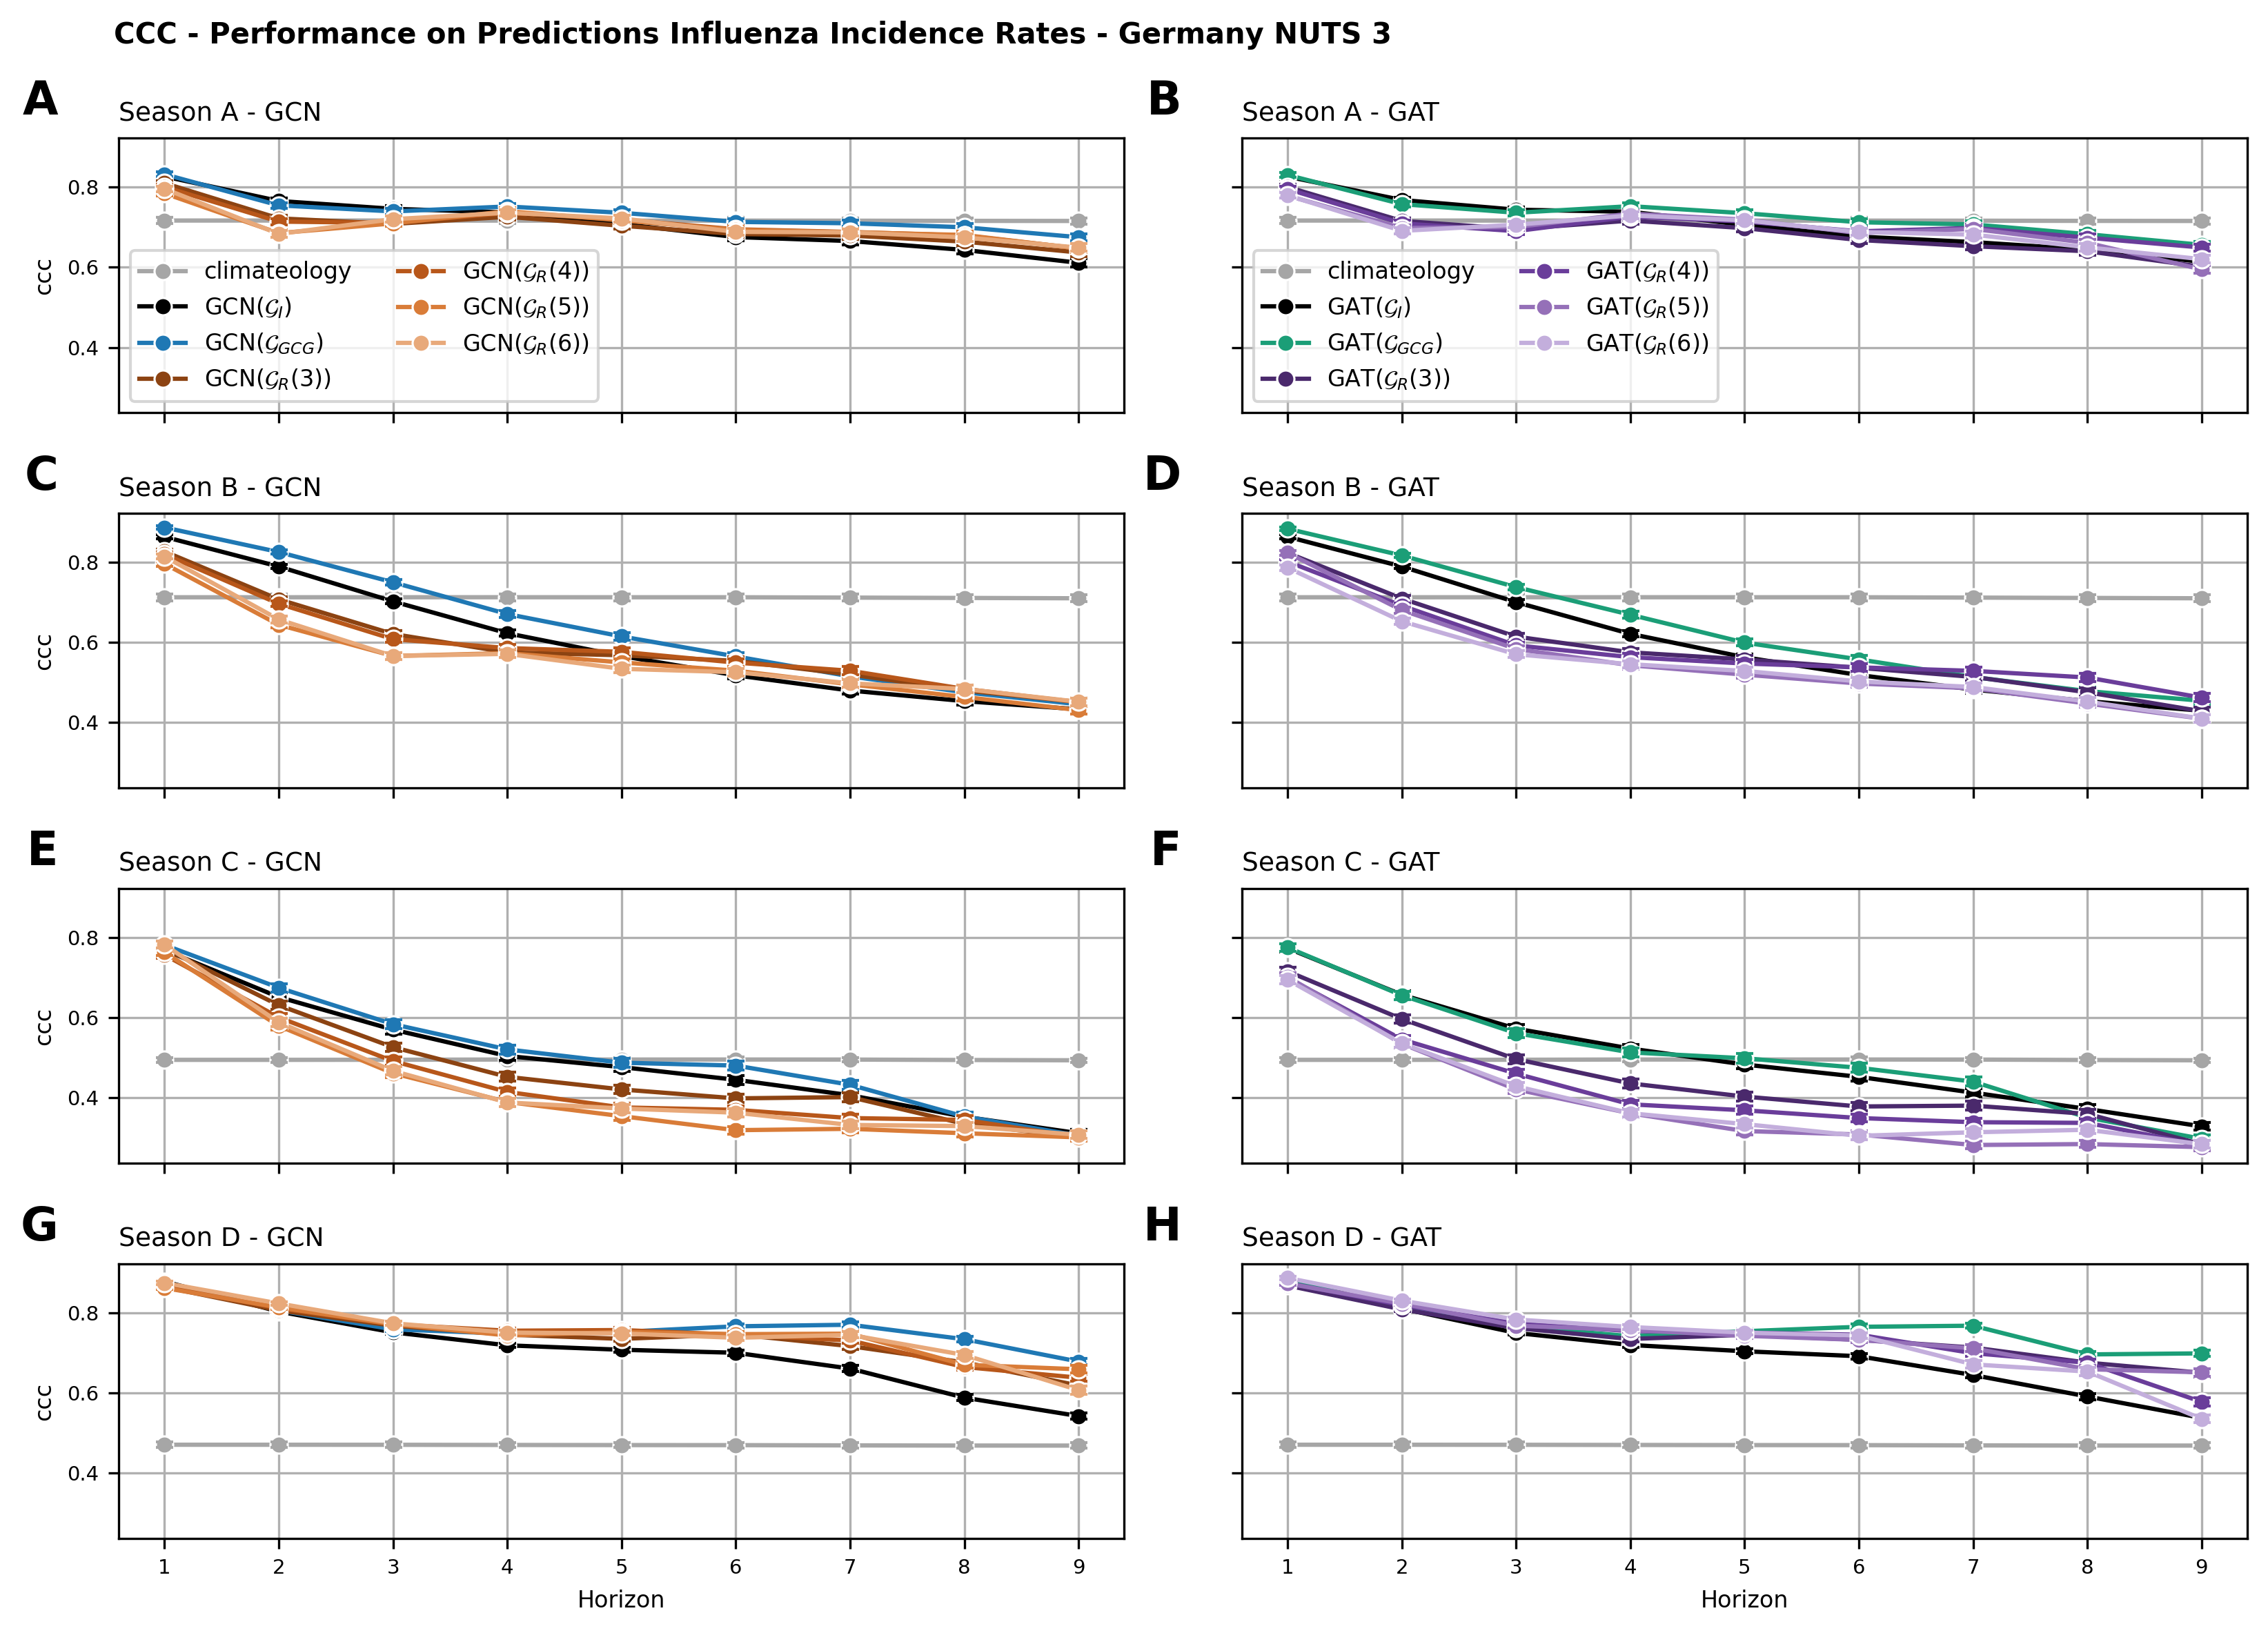

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# from figure_style import FigureStyle, AxesStyle, finalize_layout

# NOTE: modeltypes is assumed already defined earlier in the notebook
# (same as figure 5's setup): modeltypes = ['gcn', 'gat'].
# Re-define it here if this runs standalone.

# --------------------------------------------------------------------------
# Style definitions
# --------------------------------------------------------------------------

figure7_style = FigureStyle(
    figsize=(11, 8),
    suptitle="CCC - Performance on Predictions Influenza Incidence Rates - Germany NUTS 3",
    suptitle_args={'x':0.33}
)

metric = "ccc"
experiments = [exp1a, exp1b, exp1c, exp1d]
baseline_types = ["climateology"]

n_rows = len(experiments)
n_cols = 2
last_row = n_rows - 1
tags = [chr(ord("A") + i) for i in range(n_rows * n_cols)]

legend_args = {"ncols": 2, "title_fontproperties": {"weight": "bold"}}
legend_labels = {
    # gcn
    'gcngraph1' : r'GCN($\mathcal{G}_{I}$)',
    'gcngraph2' : r'GCN($\mathcal{G}_{GCG}$)',
    'gcngraph3' : r'GCN($\mathcal{G}_{R}(3)$)',
    'gcngraph4' : r'GCN($\mathcal{G}_{R}(4)$)',
    'gcngraph5' : r'GCN($\mathcal{G}_{R}(5)$)',
    'gcngraph6' : r'GCN($\mathcal{G}_{R}(6)$)',
    # gat
    'gatgraph1' : r'GAT($\mathcal{G}_{I}$)',    
    'gatgraph2' : r'GAT($\mathcal{G}_{GCG}$)',
    'gatgraph3' : r'GAT($\mathcal{G}_{R}(3)$)',
    'gatgraph4' : r'GAT($\mathcal{G}_{R}(4)$)',
    'gatgraph5' : r'GAT($\mathcal{G}_{R}(5)$)',
    'gatgraph6' : r'GAT($\mathcal{G}_{R}(6)$)',
}

seasons = ['Season A', 'Season B', 'Season C', 'Season D']

axes_styles = []
for idx in range(n_rows * n_cols):
    row = idx // n_cols
    col = idx % n_cols
    axes_styles.append(
        AxesStyle(
            tag=tags[idx],
            title = f'{seasons[row]} - {model_types[col].upper()}',
            label_y=metric if col == 0 else None,
            label_x="Horizon" if row == last_row else None,
            ticks_x_labels=(row == last_row),  # sharex=True -> only bottom row
            ticks_y_labels=(col == 0),         # sharey=True -> only left column
            legend=(row == 0),
            legend_args=legend_args if row == 0 else {},
            legend_labels = legend_labels if row == 0 else {},
            show_grid=True,
        )
    )

# --------------------------------------------------------------------------
# Data setup
# --------------------------------------------------------------------------

for experiment in experiments:
    experiment._set_modelcolors()

# --------------------------------------------------------------------------
# Build the grid + plot content first
# --------------------------------------------------------------------------

fig, axes = plt.subplots(n_rows, n_cols, figsize=figure7_style.figsize, sharex=True, sharey=True)
axes = list(axes.flatten())

for idx, ax in enumerate(axes):
    row = idx // n_cols
    col = idx % n_cols
    model_type = modeltypes[col]
    exp = experiments[row]

    summary = exp.summarize_absolute_metric(metric)

    for ml in summary["model"].unique():
        if ml.startswith(model_type) or ml in baseline_types:
            subset = summary[summary["model"] == ml]
            sns.lineplot(subset, x="hl", y="mean", c=exp.model_colors[ml], ax=ax, marker="o", label=ml)
            ax.errorbar(
                x=subset["hl"],
                y=subset["mean"],
                yerr=subset["sem"],
                fmt="none",
                capsize=3,
                color=exp.model_colors[ml],
            )

# --------------------------------------------------------------------------
# Apply standardized styling -- replaces the manual ylabel/xlabel/tag/legend code
# --------------------------------------------------------------------------

fig, axes = finalize_layout(
    fig,
    axes,
    figure7_style,
    axes_styles,
)
fig.tight_layout()
# Regular subplots() grid -- already aligned, no align_axes_to_reference() needed.

# --------------------------------------------------------------------------
# Save
# --------------------------------------------------------------------------

# from src.utils import PathManager
# pathmanager = PathManager()
fig.savefig(pathmanager.results / "figure7.svg", bbox_inches="tight", dpi=figure7_style.dpi)
fig.savefig(pathmanager.results / "figure7.pdf", bbox_inches="tight", dpi=figure7_style.dpi)
fig.savefig(pathmanager.results / "figure7.eps",bbox_inches="tight",dpi=figure7_style.dpi)

# Supplementary materials

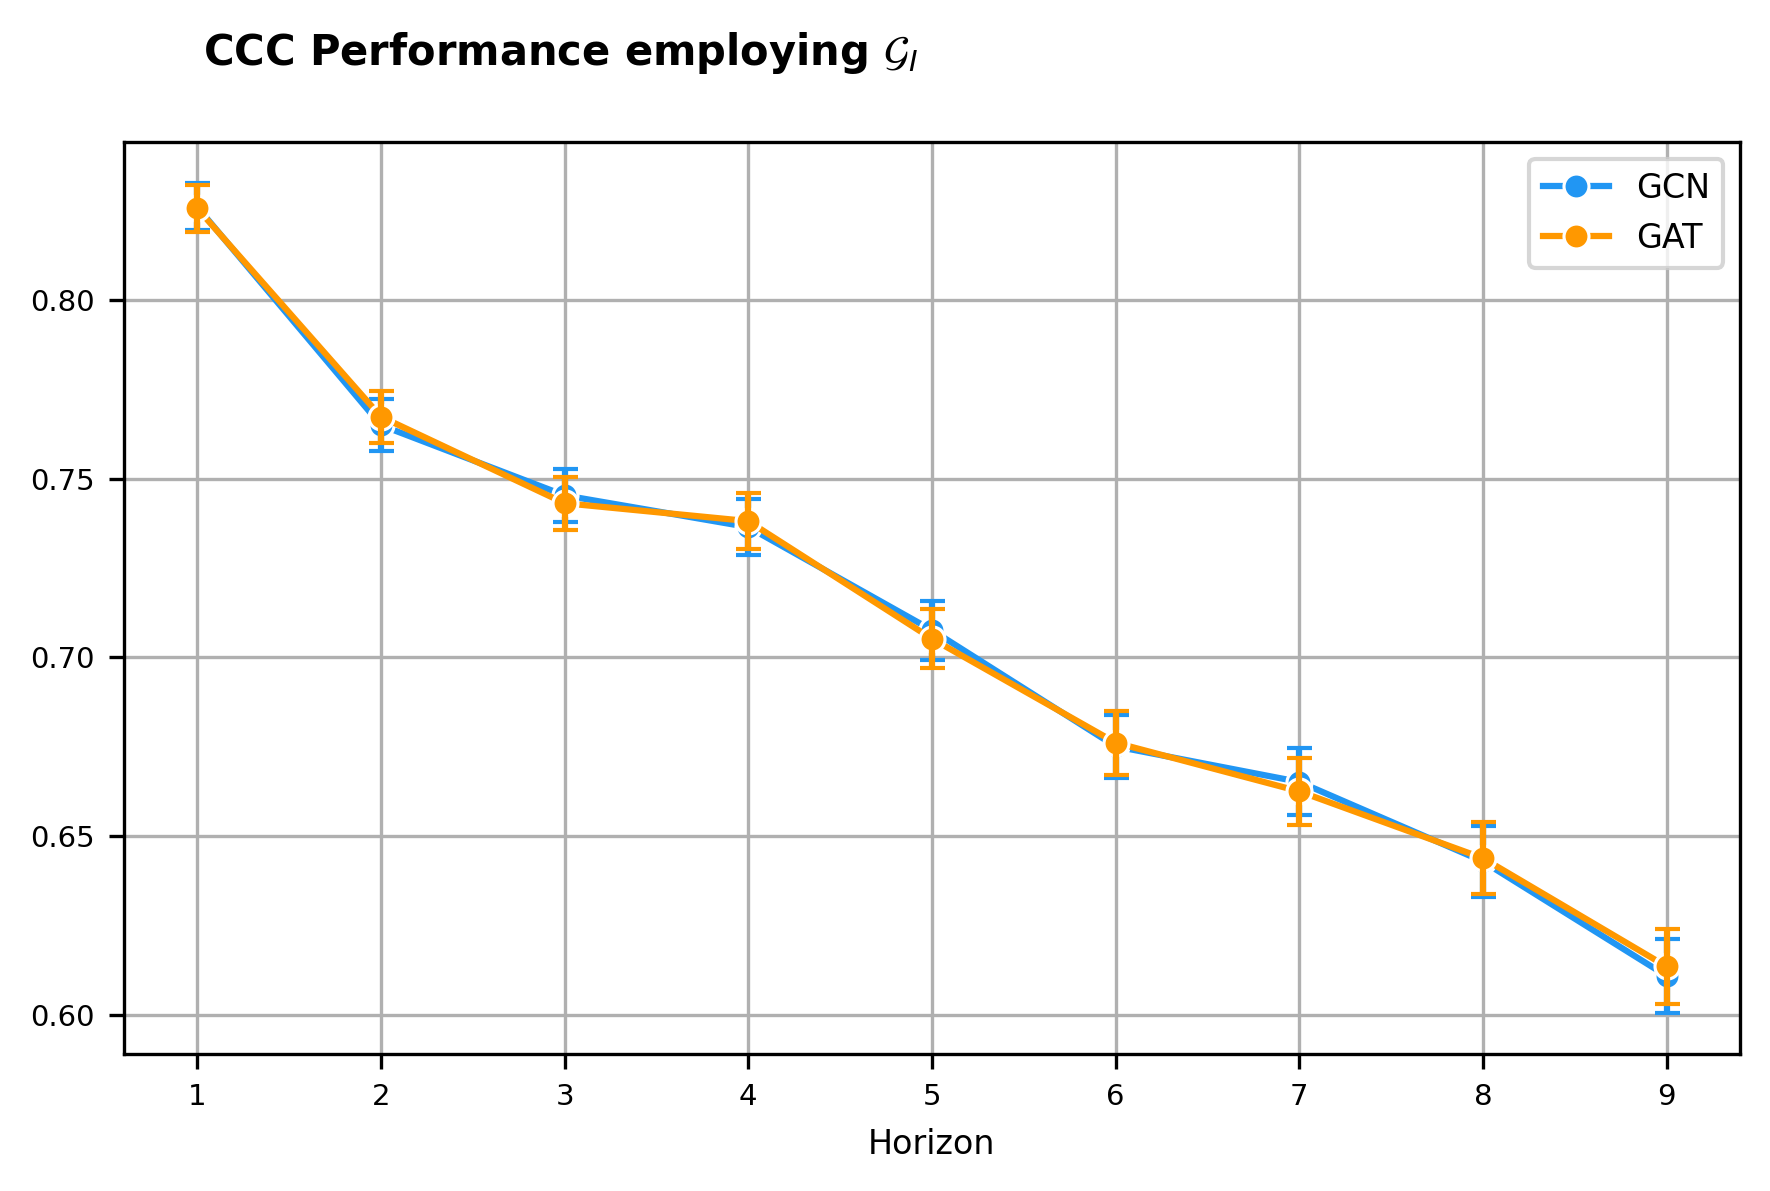

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# from figure_style import FigureStyle, AxesStyle, finalize_layout

# NOTE: `graph` is assumed already defined earlier in the notebook (e.g.
# graph = 'graph2'). With graph=None this expands to 4 graphs x 2 model
# types = 8 models -- the original color dict only had 2 entries
# (models[0], models[1]) and would KeyError on the 3rd model onward.
# Fixed below to key colors by model_type prefix instead, so it works
# regardless of how many graphs end up in `models`.

# --------------------------------------------------------------------------
# Style definitions
# --------------------------------------------------------------------------

figure8_style = FigureStyle(
    figsize=(6, 4),
    suptitle = r"CCC Performance employing $\mathcal{G}_{I}$",
    suptitle_args={"x":0.32}
)

axes_style = AxesStyle(
    legend=True,
    show_grid=True,
    label_x="Horizon",
    legend_labels = {
         'gcngraph1' : 'GCN',
         'gatgraph1' :'GAT'
    }
)

# --------------------------------------------------------------------------
# Data setup
# --------------------------------------------------------------------------

metric = "ccc"
df = exp1a.summarize_absolute_metric(metric)
graph = 'graph1'
model_types = ["gcn", "gat"]
graphs = [graph] if graph is not None else ["graph1", "graph2", "graph3", "graph4","graph5","graph6"]
models = [x + y for x in model_types for y in graphs]

palette = ["#2196F3", "#FF9800"]
color_by_type = {mt: palette[i] for i, mt in enumerate(model_types)}

# --------------------------------------------------------------------------
# Build the plot
# --------------------------------------------------------------------------

fig, ax = plt.subplots(1, 1, figsize=figure8_style.figsize)

for ml in models:
    color = next(color_by_type[mt] for mt in model_types if ml.startswith(mt))
    subset = df[df["model"] == ml]
    sns.lineplot(subset, x="hl", y="mean", c=color, ax=ax, marker="o", label=ml)
    ax.errorbar(
        x=subset["hl"],
        y=subset["mean"],
        yerr=subset["sem"],
        fmt="none",
        capsize=3,
        color=color,
    )

# --------------------------------------------------------------------------
# Apply standardized styling -- replaces the repeated title/label/legend
# calls inside the loop
# --------------------------------------------------------------------------

fig, axes = finalize_layout(
    fig,
    [ax],
    figure8_style,
    [axes_style],
)

plt.tight_layout()

# --------------------------------------------------------------------------
# Save
# --------------------------------------------------------------------------

# from src.utils import PathManager
# pathmanager = PathManager()
fig.savefig(pathmanager.results / "figure8.svg", bbox_inches="tight", dpi=figure8_style.dpi)
fig.savefig(pathmanager.results / "figure8.pdf", bbox_inches="tight", dpi=figure8_style.dpi)
fig.savefig(pathmanager.results / "figure8.eps",bbox_inches="tight",dpi=figure8_style.dpi)

In [6]:
# Global shapedata map
import matplotlib.pyplot as plt 
import seaborn as sns
import geopandas as gpd
import numpy as np
from src.graphconstruction.graphobjects import GraphStructure

graph1 = exp1a.dataloadermanagers[1].graphs['graph1'].dataloader_main.data_list[0].graph
graph2 = exp1a.dataloadermanagers[1].graphs['graph2'].dataloader_main.data_list[0].graph
graph3 = exp1a.dataloadermanagers[1].graphs['graph3'].dataloader_main.data_list[0].graph
graph6 = exp1a.dataloadermanagers[1].graphs['graph6'].dataloader_main.data_list[0].graph

global_shapedata =exp1a.dataloadermanagers[1].graphs['graph1'].dataorchestrator.data_context.global_shapedata
local_shapedata = exp1a.dataloadermanagers[1].graphs['graph1'].dataorchestrator.data_context.local_shapedata
tokenization_map =exp1a.dataloadermanagers[1].graphs['graph1'].dataorchestrator.data_context.tokenization_map

def get_neighborhood(graph: GraphStructure, key: int):

    token          = tokenization_map[key]
    adj            = graph._get_adjacency_matrix().numpy()
    adj_token      = adj[:,token]
    neighborhood    = np.where(adj_token > 0)[0]
    return neighborhood


key2 = '02000' # => Hamburg
key1 = '11000' # => Berlin
key3 = '09175' # => Ebersberg


from src.utils import traincolor, valcolor, testcolor
nb1 = traincolor
nb2 = valcolor
nb3 = '#d95f02'

local_shapedata_point = local_shapedata.copy()
local_shapedata_point['geometry'] = local_shapedata_point['geometry'].representative_point()

global_shapedata_point = global_shapedata.copy()
global_shapedata_point['geometry'] = global_shapedata_point['geometry'].representative_point()


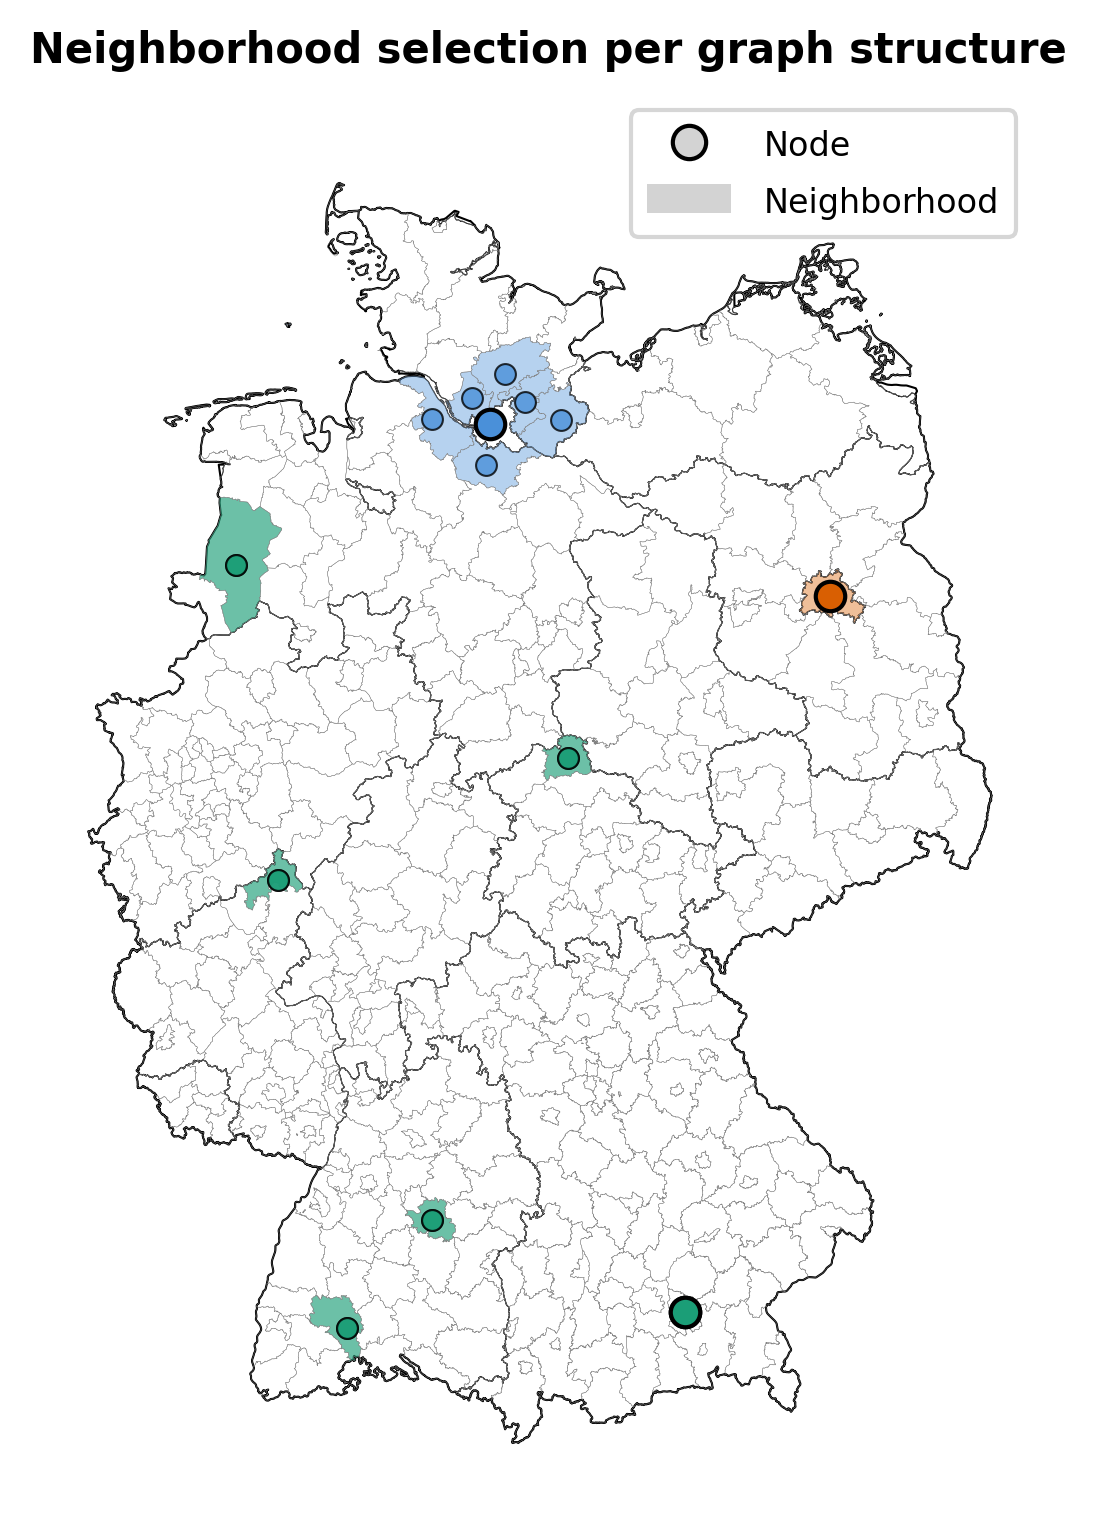

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

figure1_style = FigureStyle(
    figsize=(8, 6),
    suptitle="Neighborhood selection per graph structure",
    suptitle_args= { "ha": "left","x": 0.3, "y":0.93}
)

figure1_axstyle = AxesStyle(
    ticks_x=False,
    ticks_y=False,
    legend=True,
    spines=False
)


fig, ax = plt.subplots(1, 1, figsize=figure1_style.figsize)


global_shapedata[global_shapedata['level'] == 'nuts0'].plot(ax = ax, facecolor = 'none', edgecolor = 'black', linewidth = 0.5)
global_shapedata[global_shapedata['level'] == 'nuts1'].plot(ax = ax, facecolor = 'none', edgecolor = 'black', linewidth = 0.25)

local_shapedata[local_shapedata['node'].isin(get_neighborhood(graph2, key2))].plot(facecolor = nb1, alpha = 0.4, ax = ax)

local_shapedata[local_shapedata['node'].isin(get_neighborhood(graph6, key3))].plot(facecolor = nb2, alpha = 0.4, ax = ax)

local_shapedata[local_shapedata['node'].isin(get_neighborhood(graph6, key3))].plot(facecolor = nb2, alpha = 0.4, ax = ax)

local_shapedata[local_shapedata['node'].isin(get_neighborhood(graph1, key1))].plot(facecolor = nb3, alpha = 0.4, ax = ax)

global_shapedata[global_shapedata['level'] == 'nuts3'].plot(ax = ax, facecolor = 'none', edgecolor = 'grey', linewidth = 0.1)

global_shapedata_point[global_shapedata_point['key'] == key2].plot(color = nb1, ax = ax, edgecolor = 'black', markersize=50)
local_shapedata_point[local_shapedata_point['node'].isin(get_neighborhood(graph2, key2))].plot(color = nb1, ax = ax, alpha = 0.8, edgecolor = 'black', markersize = 25, linewidth=0.5)
global_shapedata_point[global_shapedata_point['key'] == key3].plot(color = nb2, ax = ax, edgecolor = 'black', markersize=50)
local_shapedata_point[local_shapedata_point['node'].isin(get_neighborhood(graph6, key3))].plot(color = nb2, ax = ax, alpha = 0.8, edgecolor = 'black', markersize = 25, linewidth=0.5)
global_shapedata_point[global_shapedata_point['key'] == key3].plot(color = nb2, ax = ax, edgecolor = 'black', markersize=50)
local_shapedata_point[local_shapedata_point['node'].isin(get_neighborhood(graph6, key3))].plot(color = nb2, ax = ax, alpha = 0.8, edgecolor = 'black', markersize = 25, linewidth=0.5)
global_shapedata_point[global_shapedata_point['key'] == key1].plot(color = nb3, ax = ax, edgecolor = 'black', markersize=50)


from matplotlib.lines import Line2D
from matplotlib.patches import Patch

legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor="lightgrey",
        markeredgecolor="black",
        markersize=8,
        label="Node",
    ),
    Patch(
        facecolor="lightgrey",
        edgecolor="none",
        label="Neighborhood",
    ),
]

ax.legend(handles=legend_handles,
          bbox_to_anchor=(1.0, 1.022))

fig, ax = finalize_layout(
    fig,
    ax,
    figure1_style,
    figure1_axstyle,
)

from src.utils import PathManager
pathmanager = PathManager()
fig.savefig(pathmanager.results / "figure1.svg", bbox_inches="tight", dpi=figure1_style.dpi)
fig.savefig(pathmanager.results / "figure1.pdf", bbox_inches="tight", dpi=figure1_style.dpi)
fig.savefig(pathmanager.results / "figure1.eps",bbox_inches="tight",dpi=figure1_style.dpi)